# Craton boundary framework: seismic VSH clustering vs mineral deposits

**Cluster K: Mineral exploration.**

Cratons — the ancient, cold, seismically fast cores of continents — dominate the lithosphere at 150-250 km depth. Their **edges**, marked by steep lateral gradients in horizontal shear-wave velocity (VSH), host a disproportionate share of Earth's sediment-hosted mineral systems (Pb-Zn, Cu, Ni, IOCG). *Why* has been the subject of decades of debate — cratonic keels are refractory rather than fertile, so the fertility must come from the *edge* geometry, not the interior.

**Hoggard et al. (2020)** first showed that \~85% of sediment-hosted base metal deposits sit within 200 km of the thick-thin lithosphere transition — a robust but imprecise statement, because a 200 km search radius is much larger than a typical exploration lease, and because not every thick-lithosphere region is actually a craton (some are accreted orogens or thick volcanic arcs). **Shirmard et al. (2025, *Geosci. Front.*)** sharpen this considerably by using the **REVEAL** global full-waveform seismic tomography model (Thrastarson et al. 2024, *BSSA*) to segment the lithosphere into velocity-defined classes at 150-200 km depth, then filtering the high-velocity class against the TC1 thermal model (Artemieva 2006) to isolate *actual* Archean-cratonic keels. In their global result, \~85% of the total Cu+Pb+Zn metal content in target deposits lies within just \~120 km of a REVEAL-mapped craton boundary — and >80% of craton-hosted deposits, including all giants, are within \~90 km. That is a precision improvement of roughly 2x over the earlier thermal-thickness proxy.

**Shirmard et al. (2026, *Nat. Commun.*)** then ask *why* only some craton edges are fertile. Their answer:

- **Mineralised craton edges cluster 800-1800 km from a subduction zone at the time of ore formation** (some out to \~3000 km) — a spatial pattern statistically distinct from the distribution of random craton edges.
- Geodynamic modelling shows subduction generates broad **mantle return-flow cells** that focus lithospheric stress, strain and weakening at exactly those distances from the trench.
- The mechanically weakened craton edge then promotes rifting → enhanced permeability → infiltration of slab-derived volatiles → **metallogenic preconditioning**.

This notebook implements the *craton-edge-detection* half of the Shirmard workflow: unsupervised PCA + KMeans clustering of the REVEAL 150-200 km VSH stack, boundary-polyline extraction, and ore-tonnage-weighted CDF of deposit distance to those boundaries. **§19** then hooks into GPlately to reconstruct deposits to their formation-age paleo-positions — the same operation Shirmard et al. 2026 use to measure the 800-1800 km subduction-to-craton-edge distance at ore-formation time.

The bundled inputs are (a) six global VSH slices at 150-200 km depth (0.5° grids), (b) a continental-polygon mask, and (c) 1475 mineral deposits with type, coordinates, formation age, and ore-tonnage attributes.

## What this notebook produces

1. **§1-3** — Load six VSH depth slices, clip to continental crust.
2. **§4-6** — PCA over the depth stack, elbow-method plot for `N_CLUSTERS`, KMeans clustering.
3. **§7-8** — Rasterise class labels to GeoTIFF; convert to boundary polylines.
4. **§9-10** — Load `All_Deposits.shp`; compute geodesic distance from every deposit to the nearest cluster boundary.
5. **§11-14** — Four pyGMT paleo-map-style renderings: cluster boundaries + deposits (lon/lat), boundaries-only Mollweide, filled cluster map coloured by VSH range, and a target-cluster-only inside/outside view.
6. **§15-18** — Ore-tonnage-weighted CDFs of deposit distance to boundaries: combined, per deposit type, and overlaid.
7. **§19** — Paleogeographic reconstruction of the deposits via GPlately (Cao 2024, 0-1.8 Ga coverage) — reads the modern craton-boundary framework against paleogeographic context.
8. **§20** — Export a tidy results table.

## Learning objectives

- Load and stack multi-depth global tomography (VSH GeoTIFFs) and mask to continental crust.
- Reduce dimensionality with PCA and choose `N_CLUSTERS` from an elbow-method inertia curve.
- Convert a cluster label raster into shapefile-style boundary polylines (`rasterio.features.shapes` → shapely `LineString`).
- Compute geodesic distance from a set of points to a set of polylines using a spherical-Earth `cKDTree`.
- Build ore-tonnage-weighted CDFs of distance-to-nearest-boundary and interpret them by deposit type.
- Reconstruct point data to a chosen paleo-age via `gplately.PlateReconstruction` + `gplately.Points`.
- Render every figure through pyGMT — including line charts, filled polygons and step-post CDFs.

## Prerequisites and runtime

- Bundled data at `data/craton_boundary_framework/` (\~16 MB): six VSH GeoTIFFs (`vsh_at_{150..200}km_original.tif`, extracted from the **REVEAL** global full-waveform seismic tomography model of Thrastarson et al. 2024 at 150-200 km depth), `ContinentalPolygons.shp` (continental-crust mask), and `All_Deposits.shp` (the 2166-deposit global compilation of Hoggard et al. 2020, augmented with formation-age and ore-tonnage attributes as used by Shirmard et al. 2025/2026).
- Python: `rasterio`, `geopandas`, `shapely`, `scikit-learn`, `scipy`, `pyproj`, `pygmt`, `gplately`, `pygplates`, `plate_model_manager`.
- Runtime: \~2 min (KMeans over \~O(10⁴) grid cells + geodesic distances for \~O(10³) deposits + a Cao 2024 plate-model download on first run).


## 0. Setup — install & import

In [1]:
# Uncomment on first run / new environment
# %pip install rasterio pandas geopandas shapely scikit-learn scipy pygmt gplately openpyxl -q


In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from rasterio.features import shapes
from shapely.geometry import shape, LineString, box
import xarray as xr

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from pyproj import Transformer

import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

pd.set_option("display.max_columns", 50)


def _split_wide_polygon(geom):
    """Split any polygon whose bbox is wider than 180° at lon=0 so it does not
    stretch across a Mollweide/Winkel-Tripel plot as a horizontal line."""
    if geom is None or geom.is_empty:
        return []
    minx, miny, maxx, maxy = geom.bounds
    if maxx - minx <= 179.9:
        return [geom]
    west = geom.intersection(box(-180, -90, 0, 90))
    east = geom.intersection(box(0, -90, 180, 90))
    out = []
    for g in (west, east):
        if g.is_empty: continue
        if g.geom_type == "Polygon": out.append(g)
        elif g.geom_type in ("MultiPolygon", "GeometryCollection"):
            out.extend([q for q in g.geoms if q.geom_type == "Polygon"])
    return out


def fix_antimeridian(gdf):
    """Apply _split_wide_polygon to every (multi)polygon row of a GeoDataFrame."""
    rows = []
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None: continue
        parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for part in parts:
            for split in _split_wide_polygon(part):
                d = row.drop("geometry").to_dict()
                d["geometry"] = split
                rows.append(d)
    return gpd.GeoDataFrame(rows, geometry="geometry", crs=gdf.crs)


def nice_legend_values(lo, hi, n=2):
    """Return `n` round-number values spanning [lo, hi] for legend samples."""
    lo, hi = max(lo, 1e-6), max(hi, lo * 10)
    logspace = np.logspace(np.log10(lo), np.log10(hi), n)
    return [float(f"{v:.1g}") for v in logspace]


## 1. USER CONFIGURATION — edit these paths & parameters

Point `SEISMIC_DIR` and `DEPOSITS_SHP` at your data. Depths, cluster count, and the
tonnage/weight field are all adjustable here so nothing else in the notebook needs editing.


In [3]:
# === USER CONFIGURATION ===================================================
# ---- Input paths (bundled at data/craton_boundary_framework/) ----
# House convention: work from the suite root, not from Notebooks/, so paths
# resolve against the same data/ folder every other tutorial uses.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

SEISMIC_DIR    = "data/craton_boundary_framework"                           # 6 VSH GeoTIFFs
DEPOSITS_SHP   = "data/craton_boundary_framework/All_Deposits.shp"          # deposits point shapefile
CONTINENTS_SHP = "data/craton_boundary_framework/ContinentalPolygons.shp"   # continent mask
OUTPUT_DIR     = "Notebooks/T72_cbf_outputs"                                # gitignored working dir

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Clip the VSH grid (and therefore all downstream clustering/boundaries) to land only ----
CLIP_TO_CONTINENTS = True

# ---- Map styling ----
CLUSTER_FILL_ALPHA = 0.6     # transparency of the cluster color fill (Section 13), 0=invisible, 1=opaque
USE_SATELLITE_BASEMAP = True  # True = draw a real satellite ("Google Earth style") image behind the maps.
                                 # Requires internet access in this environment (fetches map tiles) — leave
                                 # False for fully offline runs; the maps still render fine without it.
# Satellite basemap for Sections 11-13: Esri World Imagery via contextily (same source, same fetch
# mechanism, for all three maps -- reliable and doesn't need any extra config beyond the zoom level).
SATELLITE_ZOOM = 3  # higher = sharper but much slower/heavier download for a world map

# ---- Depth slices to use (km) ----
DEPTHS = [150, 160, 170, 180, 190, 200]
TIF_FILES = {d: os.path.join(SEISMIC_DIR, f"vsh_at_{d}km_original.tif") for d in DEPTHS}

# ---- Clustering ----
N_CLUSTERS   = 5          # KMeans cluster count (see elbow plot below to tune); overridden below if USE_FIXED_VSH_BINS
N_PCA_COMPONENTS = len(DEPTHS)
CLUSTER_ON   = ["PC1"]    # which principal component(s) KMeans clusters on (["PC1"] matches your original notebook;
                           # try ["PC1", "PC2"] etc. for multivariate clustering)

# ---- Fixed VSH-value classification (instead of / alongside data-driven KMeans clusters) ----
# When True, the map's 5 classes are assigned directly from these mean-VSH (km/s) breakpoints
# rather than from the KMeans cluster labels -- useful for reproducing a specific published
# classification exactly. KMeans/PCA/Elbow still run below (handy for comparison / choosing your
# own breakpoints) but the rasterized map, boundaries, and legend use the fixed bins when this is on.
USE_FIXED_VSH_BINS = True
VSH_BIN_EDGES = [4.04, 4.39, 4.49, 4.58, 4.68, 4.99]  # 5 classes: bin i = [VSH_BIN_EDGES[i], VSH_BIN_EDGES[i+1])
if USE_FIXED_VSH_BINS:
    N_CLUSTERS = len(VSH_BIN_EDGES) - 1

# ---- Which ordered class (1 = lowest VSH .. N_CLUSTERS = highest VSH) to isolate for the
# single-cluster boundary map + its own CDFs (Sections 14-17) ----
TARGET_CLUSTER_RANK = 4

# ---- Deposit fields (from your shapefile schema) ----
TYPE_FIELD     = "Type"        # deposit type / commodity class
TONNAGE_FIELD  = "Ore_Tonnag"  # "Ore_Tonnage" (truncated to 10 chars by the shapefile format)
TONNAGE_FALLBACK_FIELD = "Ore__Mt_"   # used only to fill genuinely missing tonnage records, see Section 3
EXCLUDE_TYPES  = ["Magmatic_Ni", "VMS"]   # excluded everywhere in this notebook (map, both CDF plots)

# ---- Distance grid resolution (deg) — must match the VSH raster resolution ----
PIXEL_SIZE = 0.5

print("Depth slices:", DEPTHS)
print("Deposits shapefile:", DEPOSITS_SHP)


Depth slices: [150, 160, 170, 180, 190, 200]
Deposits shapefile: data/craton_boundary_framework/All_Deposits.shp


## 2. Load & merge the VSH depth slices

Each GeoTIFF is flattened into (x, y, value) and merged into one table, one column per depth.


In [4]:
vsh_frames = []
for d in DEPTHS:
    with rasterio.open(TIF_FILES[d]) as src:
        data = src.read(1)
        rows, cols = data.shape
        row_idx, col_idx = np.meshgrid(np.arange(rows), np.arange(cols), indexing="ij")
        xcoord, ycoord = rasterio.transform.xy(src.transform, row_idx.ravel(), col_idx.ravel())
        df = pd.DataFrame({"x": xcoord, "y": ycoord, f"vsh_{d}km": data.ravel()})
        vsh_frames.append(df)
        raster_profile = src.profile  # keep the last profile for later rasterization

merged_df = vsh_frames[0]
for df in vsh_frames[1:]:
    merged_df = merged_df.merge(df, on=["x", "y"], how="outer")

merged_df = merged_df.dropna().reset_index(drop=True)

# Guard against invalid/duplicate coordinates at the grid edges: some source GeoTIFFs report
# pixel-center coordinates that spill slightly past +/-90 latitude, and/or duplicate the
# antimeridian seam (x=180.25 is the same meridian as x=-179.75, 360 deg away). Left in, these
# produce the classic "line stretching across the map" artifact once reprojected to Mollweide.
n_before = len(merged_df)
merged_df = merged_df[(merged_df["y"] >= -90) & (merged_df["y"] <= 90) &
                       (merged_df["x"] >= -180) & (merged_df["x"] < 180)].reset_index(drop=True)
print(f"Dropped {n_before - len(merged_df)} out-of-range / duplicate-seam grid points")

merged_df.to_csv(os.path.join(OUTPUT_DIR, "VSH_merged.csv"), index=False)
print(f"Merged VSH grid: {merged_df.shape[0]:,} points x {len(DEPTHS)} depth slices")
merged_df.head()


Dropped 1081 out-of-range / duplicate-seam grid points


Merged VSH grid: 259,200 points x 6 depth slices


,x,y,vsh_150km,vsh_160km,vsh_170km,vsh_180km,vsh_190km,vsh_200km
0,-179.75,-89.75,4.587278,4.590530,4.593837,4.597198,4.600614,4.604084
1,-179.75,-89.25,4.531467,4.536096,4.540805,4.545598,4.550472,4.555428
2,-179.75,-88.75,4.467239,4.472057,4.477308,4.482993,4.489110,4.495662
3,-179.75,-88.25,4.418054,4.421657,4.425910,4.430814,4.436369,4.442574
4,-179.75,-87.75,4.375507,4.378230,4.381548,4.385460,4.389968,4.395071


## 3. Clip the VSH grid to continental polygons

Restricts every downstream step (PCA, KMeans, cluster boundaries, the filled cluster map) to
land only, matching your continental-polygon shapefile. Set `CLIP_TO_CONTINENTS = False` in the
Config cell to skip this and cluster the full global (land + ocean) grid instead.

Any polygon part that spans the full globe (Antarctica, or any coastline literally crossing the
+/-180 antimeridian) is split at lon=0 first — otherwise reprojecting it later (e.g. to Mollweide)
draws a spurious straight line stretching across the whole map from one edge to the other.


In [5]:
continents_gdf = gpd.read_file(CONTINENTS_SHP)
continents_gdf["geometry"] = continents_gdf.geometry.buffer(0)  # fix any self-intersections
continents_gdf = fix_antimeridian(continents_gdf)  # split Antarctica/date-line-crossing parts
continents_union = continents_gdf.union_all()

if CLIP_TO_CONTINENTS:
    grid_pts = gpd.GeoDataFrame(
        merged_df, geometry=gpd.points_from_xy(merged_df.x, merged_df.y), crs="EPSG:4326"
    )
    clipped_pts = gpd.sjoin(grid_pts, continents_gdf[["geometry"]], predicate="within", how="inner")
    merged_df = (
        clipped_pts.drop(columns=["geometry", "index_right"])
        .drop_duplicates(subset=["x", "y"])
        .reset_index(drop=True)
    )
    print(f"Clipped to continents: {len(merged_df):,} land grid points retained")
else:
    print("CLIP_TO_CONTINENTS is False — using the full global grid (land + ocean)")

merged_df.head()


Clipped to continents: 121,242 land grid points retained


,x,y,vsh_150km,vsh_160km,vsh_170km,vsh_180km,vsh_190km,vsh_200km
0,-179.75,-89.75,4.587278,4.590530,4.593837,4.597198,4.600614,4.604084
1,-179.75,-89.25,4.531467,4.536096,4.540805,4.545598,4.550472,4.555428
2,-179.75,-88.75,4.467239,4.472057,4.477308,4.482993,4.489110,4.495662
3,-179.75,-88.25,4.418054,4.421657,4.425910,4.430814,4.436369,4.442574
4,-179.75,-87.75,4.375507,4.378230,4.381548,4.385460,4.389968,4.395071


## 4. PCA on the VSH depth stack

In [6]:
value_cols = [f"vsh_{d}km" for d in DEPTHS]
X = merged_df[value_cols].values

pca = PCA(n_components=N_PCA_COMPONENTS)
principal_components = pca.fit_transform(X)

pca_cols = [f"PC{i+1}" for i in range(N_PCA_COMPONENTS)]
pca_df = pd.DataFrame(principal_components, columns=pca_cols)
pca_df["x"] = merged_df["x"].values
pca_df["y"] = merged_df["y"].values
pca_df["MeanVSH"] = merged_df[value_cols].mean(axis=1).values  # simple average across depth slices,
                                                                  # used for the fixed-bin classification below

eigenvalues = pca.explained_variance_
explained_pct = pca.explained_variance_ratio_ * 100
cum_pct = explained_pct.cumsum()

pca_summary = pd.DataFrame({
    "PC": pca_cols,
    "EigenValue": eigenvalues,
    "% Variance": explained_pct,
    "Cumulative %": cum_pct,
})
pca_df.to_csv(os.path.join(OUTPUT_DIR, "pca_VSH.csv"), index=False)
pca_summary


,PC,EigenValue,% Variance,Cumulative %
0,PC1,9.893380e-02,9.851054e+01,98.510541
1,PC2,1.472674e-03,1.466373e+00,99.976915
2,PC3,2.318453e-05,2.308535e-02,100.000000
3,PC4,2.677359e-14,2.665904e-11,100.000000
4,PC5,0.000000e+00,0.000000e+00,100.000000
5,PC6,0.000000e+00,0.000000e+00,100.000000


## 5. Elbow method — pick `N_CLUSTERS`

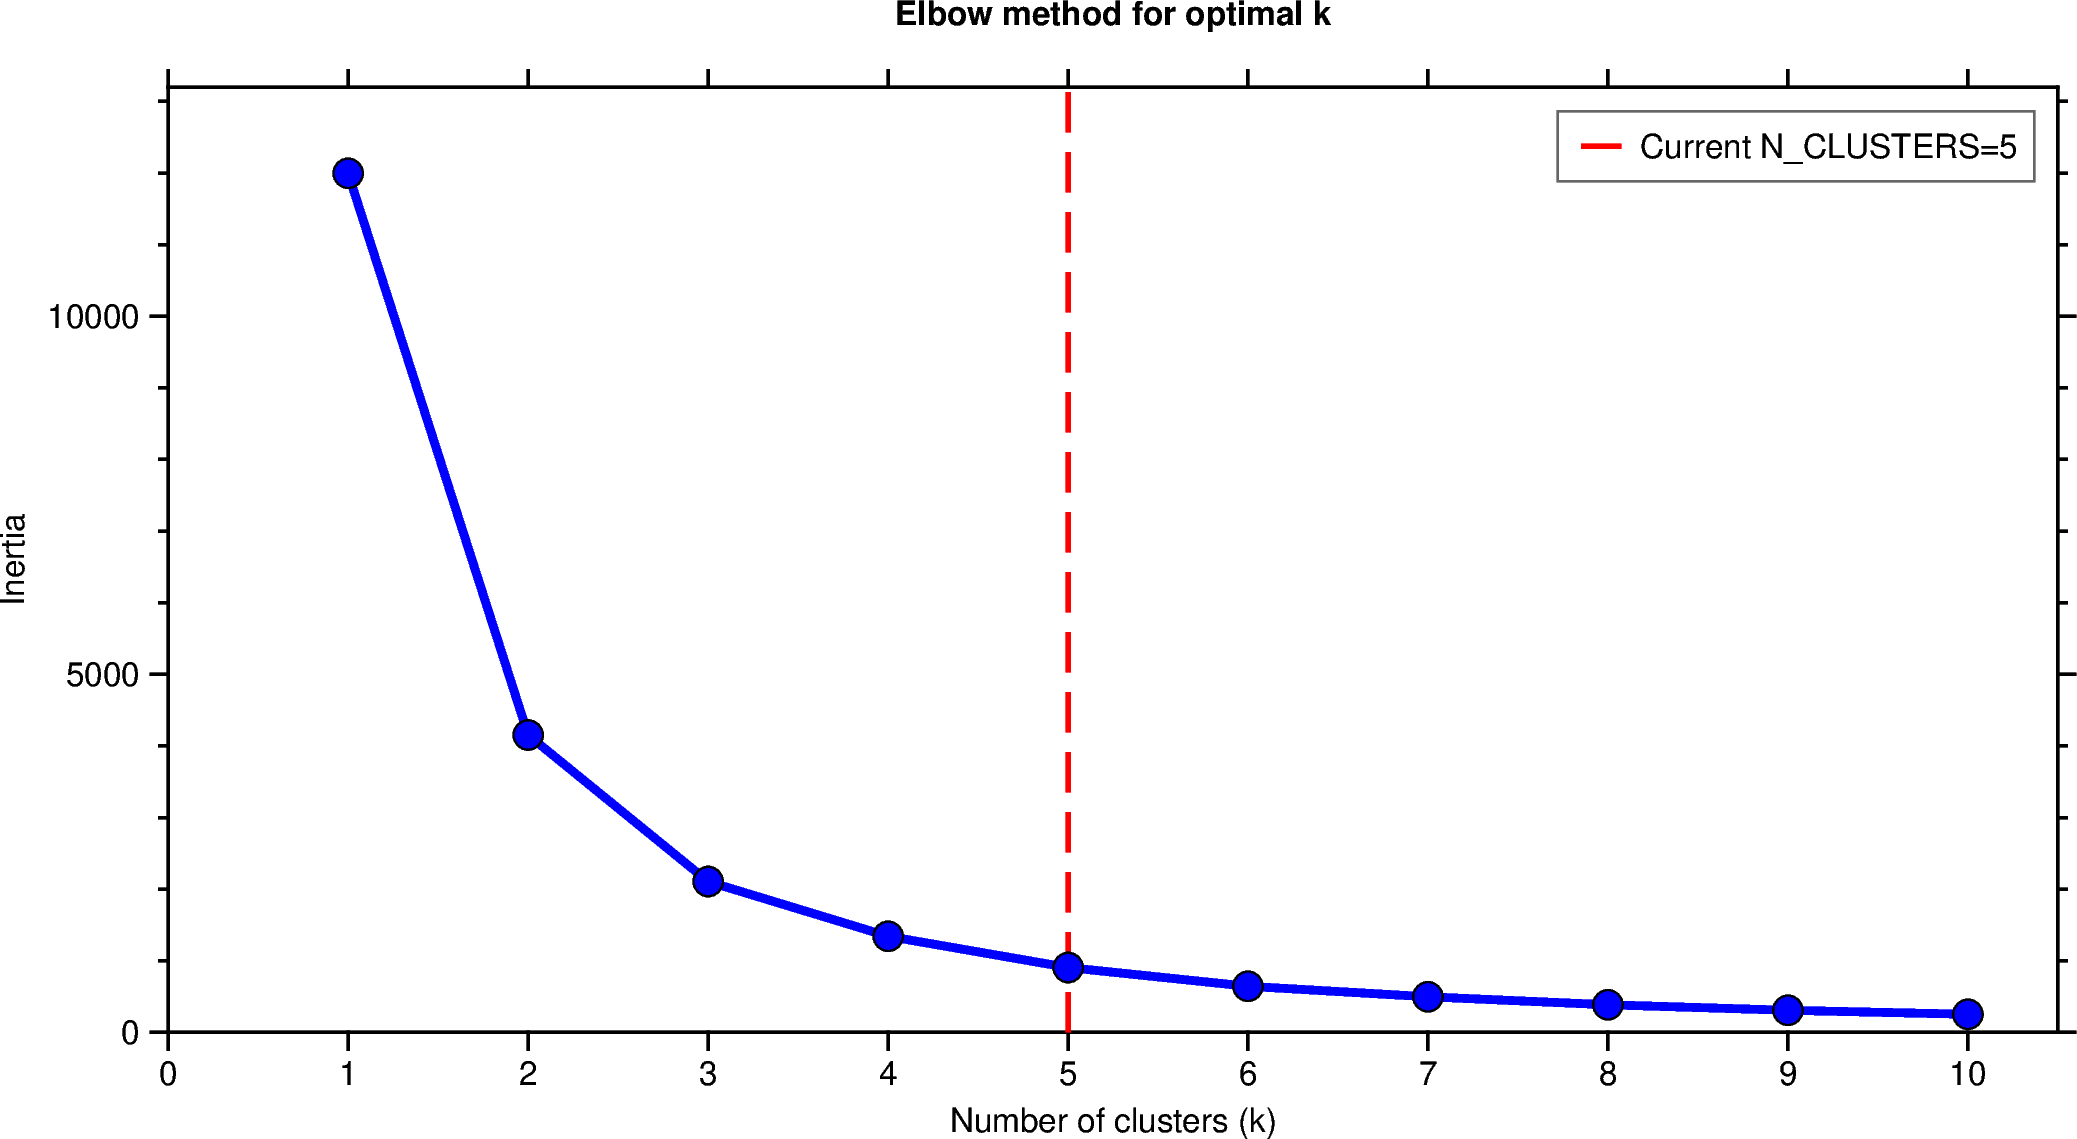

In [7]:
# Elbow-method inertia curve — pyGMT line plot
inertia = []
K = list(range(1, 11))
for k in K:
    inertia.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(pca_df[CLUSTER_ON]).inertia_)

fig = pygmt.Figure()
YMAX = max(inertia) * 1.1
fig.basemap(region=[0, max(K) + 0.5, 0, YMAX], projection="X16c/8c",
            frame=["WSne+tElbow method for optimal k",
                   "xa1+lNumber of clusters (k)", "yaf+lInertia"])
# Vertical marker at current N_CLUSTERS
fig.plot(x=[N_CLUSTERS, N_CLUSTERS], y=[0, YMAX], pen="1.2p,red,-",
         label=f"Current N_CLUSTERS={N_CLUSTERS}")
# Inertia curve
fig.plot(x=K, y=inertia, pen="2p,blue")
fig.plot(x=K, y=inertia, style="c0.25c", fill="blue", pen="0.4p,black")
fig.legend(position="JTR+jTR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=900)


### How to read the elbow plot

Inertia (sum-of-squares distance from each PCA-projected VSH sample to its assigned cluster centre) decreases monotonically as `k` grows. The "elbow" is the value beyond which extra clusters buy only marginal inertia reduction — often around `k = 4-6` for global lithospheric tomography. `N_CLUSTERS` is fixed in the CONFIG cell; the red dashed line shows where it currently sits. Move it to a different elbow if you want a coarser (few-class) or finer (many-class) craton framework.


## 6. KMeans clustering

Runs regardless of `USE_FIXED_VSH_BINS` (useful for comparison / picking your own breakpoints from
the elbow plot above), but if `USE_FIXED_VSH_BINS = True` the map in the sections below classifies
directly from `VSH_BIN_EDGES` instead of these KMeans labels — see Section 7.


In [8]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(pca_df[CLUSTER_ON])
pca_df["Cluster"] = kmeans.labels_

pca_df.to_csv(os.path.join(OUTPUT_DIR, "kmeans_VSH.csv"), index=False)
print(pca_df["Cluster"].value_counts().sort_index())


Cluster
0    14549
1    36701
2    12162
3    29723
4    28107
Name: count, dtype: int64


## 7. Rasterize class labels to GeoTIFF

Uses the fixed `VSH_BIN_EDGES` classification when `USE_FIXED_VSH_BINS = True` (default), otherwise
falls back to the KMeans cluster labels from Section 6.


In [9]:
if USE_FIXED_VSH_BINS:
    class_labels = pd.cut(
        pca_df["MeanVSH"], bins=VSH_BIN_EDGES, labels=range(1, len(VSH_BIN_EDGES)), include_lowest=True
    ).astype(int).values
    print("Using fixed VSH-value bins:", list(zip(VSH_BIN_EDGES[:-1], VSH_BIN_EDGES[1:])))
else:
    class_labels = pca_df["Cluster"].values.astype(np.int32)
    print("Using KMeans cluster labels")

x_min, x_max = pca_df["x"].min(), pca_df["x"].max()
y_min, y_max = pca_df["y"].min(), pca_df["y"].max()

n_cols = int(round((x_max - x_min) / PIXEL_SIZE)) + 1
n_rows = int(round((y_max - y_min) / PIXEL_SIZE)) + 1

cluster_raster = np.full((n_rows, n_cols), -1, dtype=np.int32)
col_idx = np.round((pca_df["x"].values - x_min) / PIXEL_SIZE).astype(int)
row_idx = n_rows - 1 - np.round((pca_df["y"].values - y_min) / PIXEL_SIZE).astype(int)
cluster_raster[row_idx, col_idx] = class_labels.astype(np.int32)

# x_min/y_max above are pixel CENTERS (from the point grid), but from_origin() expects the
# raster's outer EDGE. Anchoring directly on the center coordinate silently shifts every pixel
# by half a cell and, compounded over n_rows, overshoots the valid -90..90 latitude range at the
# bottom edge -- which is exactly what produced the spurious full-width line artifact when this
# raster's polygon boundaries were later reprojected to Mollweide. Shift by half a pixel to anchor
# on the true edge instead.
edge_x_min = x_min - PIXEL_SIZE / 2
edge_y_max = y_max + PIXEL_SIZE / 2
cluster_transform = from_origin(edge_x_min, edge_y_max, PIXEL_SIZE, PIXEL_SIZE)
cluster_tif_path = os.path.join(OUTPUT_DIR, "kmeans_clustering_VSH.tif")

with rasterio.open(
    cluster_tif_path, "w", driver="GTiff",
    height=cluster_raster.shape[0], width=cluster_raster.shape[1],
    count=1, dtype=cluster_raster.dtype, crs="EPSG:4326",
    transform=cluster_transform, nodata=-1,
) as dst:
    dst.write(cluster_raster, 1)

print("Saved:", cluster_tif_path)


Using fixed VSH-value bins: [(4.04, 4.39), (4.39, 4.49), (4.49, 4.58), (4.58, 4.68), (4.68, 4.99)]
Saved: Notebooks/T72_cbf_outputs/kmeans_clustering_VSH.tif


## 8. Extract cluster boundaries as polylines

In [10]:
with rasterio.open(cluster_tif_path) as src:
    image = src.read(1)
    mask = image != src.nodata
    shape_gen = shapes(image, mask=mask, transform=src.transform)
    poly_records, line_records = [], []
    for geom, val in shape_gen:
        poly = shape(geom)
        if poly.geom_type == "Polygon":
            poly_records.append({"raster_val": int(val), "geometry": poly})
            line_records.append({"raster_val": int(val), "geometry": poly.exterior})

# Boundary polylines (used by the outline-only maps and the distance calc)
boundaries_gdf = gpd.GeoDataFrame.from_features(
    [{"type": "Feature", "properties": {"raster_val": r["raster_val"]},
      "geometry": r["geometry"]} for r in line_records],
    crs="EPSG:4326",
)
boundaries_gdf["geometry"] = boundaries_gdf["geometry"].apply(
    lambda g: LineString(g) if g.geom_type == "LinearRing" else g
)
boundaries_gdf = boundaries_gdf[boundaries_gdf.is_valid].reset_index(drop=True)

# Filled cluster polygons (used by the filled choropleth map in Section 13)
cluster_polygons_gdf = gpd.GeoDataFrame.from_features(
    [{"type": "Feature", "properties": {"raster_val": r["raster_val"]}, "geometry": r["geometry"]}
     for r in poly_records],
    crs="EPSG:4326",
)
cluster_polygons_gdf = cluster_polygons_gdf[cluster_polygons_gdf.is_valid].reset_index(drop=True)
cluster_polygons_gdf = fix_antimeridian(cluster_polygons_gdf)  # safety net; usually a no-op for raster-derived cells

# When using fixed VSH bins, raster_val IS already the final ordered class (1..N_CLUSTERS), so the
# legend ranges are just the bin edges themselves. When using KMeans, raster_val is an arbitrary
# cluster label that needs re-ordering by mean VSH so the legend reads low -> high velocity.
if USE_FIXED_VSH_BINS:
    cluster_order_map = {i: i for i in range(1, N_CLUSTERS + 1)}
    cluster_vsh_stats_ordered = pd.DataFrame(
        {"min": VSH_BIN_EDGES[:-1], "max": VSH_BIN_EDGES[1:]},
        index=pd.Index(range(1, N_CLUSTERS + 1), name="ClusterOrdered"),
    )
else:
    cluster_vsh_stats = pca_df.groupby("Cluster")["MeanVSH"].agg(["min", "max", "mean"]).sort_values("mean")
    cluster_order_map = {old: i + 1 for i, old in enumerate(cluster_vsh_stats.index)}  # 1..N_CLUSTERS, low->high VSH
    cluster_vsh_stats_ordered = (
        cluster_vsh_stats.reset_index().assign(ClusterOrdered=lambda d: d["Cluster"].map(cluster_order_map))
        .set_index("ClusterOrdered")[["min", "max"]].sort_index()
    )

cluster_polygons_gdf["ClusterOrdered"] = cluster_polygons_gdf["raster_val"].map(cluster_order_map)
boundaries_gdf["ClusterOrdered"] = boundaries_gdf["raster_val"].map(cluster_order_map)

boundary_shp_path = os.path.join(OUTPUT_DIR, "Kmeans_Boundaries_VSH.shp")
boundaries_gdf.to_file(boundary_shp_path)
print(f"Extracted {len(boundaries_gdf)} boundary line segments -> {boundary_shp_path}")
cluster_vsh_stats_ordered


Extracted 873 boundary line segments -> Notebooks/T72_cbf_outputs/Kmeans_Boundaries_VSH.shp


/tmp/ipykernel_18541/733988879.py:53: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'ClusterOrdered' to 'ClusterOrd'


,min,max
ClusterOrdered,,
1,4.04,4.39
2,4.39,4.49
3,4.49,4.58
4,4.58,4.68
5,4.68,4.99


## 9. Load deposits & clean the tonnage field

`Ore_Tonnag` is text in the shapefile (10-char field-name limit truncated `Ore_Tonnage`) and has
missing values for many records. We coerce it to numeric and, only where it's genuinely missing,
fall back to `Ore__Mt_` so every deposit still gets a usable marker size / CDF weight.


In [11]:
deposits_gdf = gpd.read_file(DEPOSITS_SHP)
deposits_gdf = deposits_gdf[deposits_gdf.is_valid].to_crs("EPSG:4326").reset_index(drop=True)

if EXCLUDE_TYPES:
    deposits_gdf = deposits_gdf[~deposits_gdf[TYPE_FIELD].isin(EXCLUDE_TYPES)].reset_index(drop=True)

tonnage = pd.to_numeric(deposits_gdf[TONNAGE_FIELD], errors="coerce")
fallback = pd.to_numeric(deposits_gdf[TONNAGE_FALLBACK_FIELD], errors="coerce")
deposits_gdf["Tonnage"] = tonnage.fillna(fallback).fillna(0.0)

print(f"Deposits loaded: {len(deposits_gdf)}")
print(deposits_gdf[TYPE_FIELD].value_counts())
deposits_gdf[[TYPE_FIELD, "Deposit", TONNAGE_FIELD, "Tonnage"]].head()


Deposits loaded: 420
Type
PbZn-MVT    147
Cu-Sed      139
PbZn-CD     109
IOCG         25
Name: count, dtype: int64


,Type,Deposit,Ore_Tonnag,Tonnage
0,PbZn-CD,Aguilar,3.6,3.6
1,PbZn-CD,Esperanza,0,0.0
2,PbZn-CD,HYC (McArthur River),30.8,30.8
3,PbZn-CD,Myrtle,2.2,2.2
4,PbZn-CD,Cannington,7,7.0


## 10. Deposit → nearest boundary distance (geodesic, in km)

Distances are computed on the sphere (Earth-Centered-Earth-Fixed / chord-length trick with a KD-tree),
not naive planar degree-distance — this matches the geodesic approach in your commented-out
original code but runs fast on the full boundary line set via `scipy.cKDTree`.


In [12]:
EARTH_RADIUS_KM = 6371.0088

def to_ecef(lon, lat):
    lon, lat = np.radians(lon), np.radians(lat)
    x = EARTH_RADIUS_KM * np.cos(lat) * np.cos(lon)
    y = EARTH_RADIUS_KM * np.cos(lat) * np.sin(lon)
    z = EARTH_RADIUS_KM * np.sin(lat)
    return x, y, z

# Densify boundary lines into a point cloud for the KD-tree query
boundary_coords = []
for geom in boundaries_gdf.geometry:
    geoms = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
    for g in geoms:
        boundary_coords.extend(list(g.coords))
boundary_coords = np.array(boundary_coords)

bx, by, bz = to_ecef(boundary_coords[:, 0], boundary_coords[:, 1])
boundary_tree = cKDTree(np.column_stack([bx, by, bz]))

px, py, pz = to_ecef(deposits_gdf.geometry.x.values, deposits_gdf.geometry.y.values)
chord_dist, _ = boundary_tree.query(np.column_stack([px, py, pz]), k=1)

# convert chord length -> great-circle distance
deposits_gdf["Dist_to_Boundary_km"] = 2 * EARTH_RADIUS_KM * np.arcsin(
    np.clip(chord_dist / (2 * EARTH_RADIUS_KM), 0, 1)
)

deposits_out_path = os.path.join(OUTPUT_DIR, "Deposits_with_distance.shp")
deposits_gdf.to_file(deposits_out_path)

deposits_gdf[["Deposit", TYPE_FIELD, "Tonnage", "Dist_to_Boundary_km"]].describe(include="all")


/tmp/ipykernel_18541/2604148106.py:30: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Dist_to_Boundary_km' to 'Dist_to_Bo'


,Deposit,Type,Tonnage,Dist_to_Boundary_km
count,420,420,420.000000,4.200000e+02
unique,418,4,NaN,NaN
top,Broken Hill,PbZn-MVT,NaN,NaN
freq,2,147,NaN,NaN
mean,NaN,NaN,3.325738,6.184991e+01
std,NaN,NaN,9.415945,4.887816e+01
min,NaN,NaN,0.000000,7.503331e-12
25%,NaN,NaN,0.107500,2.785552e+01
50%,NaN,NaN,0.500000,4.596496e+01
75%,NaN,NaN,2.002500,8.310403e+01


## 11. Map — cluster boundaries vs. deposits

Deposit **color = Type**, marker **size = Ore_Tonnage** (sqrt-scaled). Set
`USE_SATELLITE_BASEMAP = True` in the Config cell for a real satellite ("Google Earth style")
background — requires internet access in this environment (uses `contextily` + Esri World Imagery).


Cluster colour palette: ['#2166ac', '#1b9e77', '#78c679', '#e6550d', '#a50026']


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


legend [WARNING]: File <stdin> is empty!


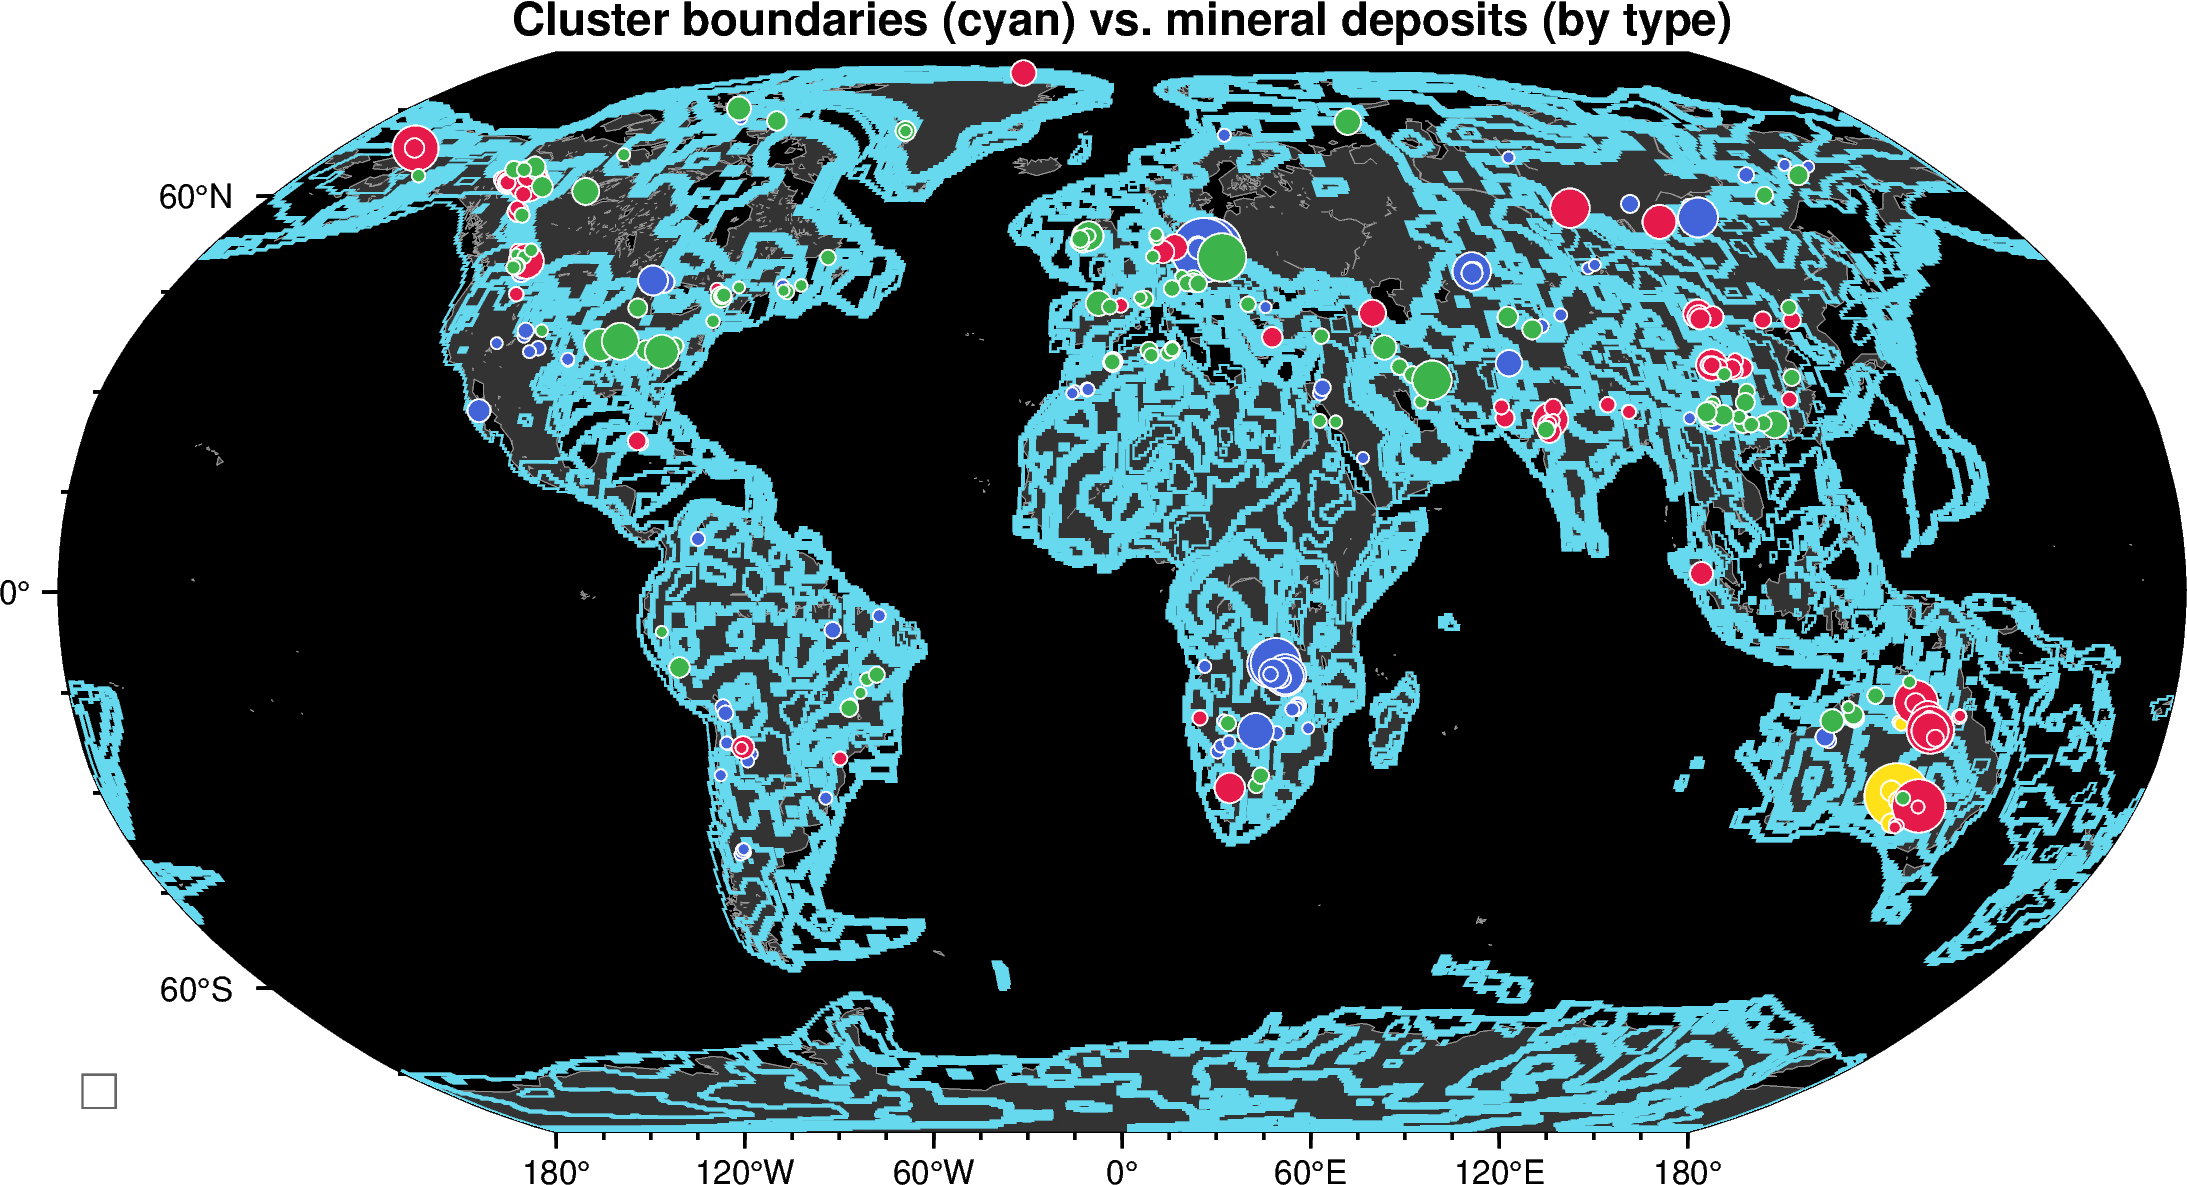

In [13]:
# Colour palette for cluster ranks — a discrete N_CLUSTERS-step gradient. Hard-coded
# hex list rather than matplotlib's LinearSegmentedColormap since we no longer import
# matplotlib. Blue (low VSH) → red (high VSH) with an intermediate green stop.
_GRADIENT_STOPS = ["#2166ac", "#1b9e77", "#78c679", "#e6550d", "#a50026"]

def _hex_lerp(a, b, t):
    ai = int(a.lstrip("#"), 16); bi = int(b.lstrip("#"), 16)
    ar, ag, ab = (ai >> 16) & 0xFF, (ai >> 8) & 0xFF, ai & 0xFF
    br, bg, bb = (bi >> 16) & 0xFF, (bi >> 8) & 0xFF, bi & 0xFF
    r = int(round(ar + (br - ar) * t))
    g = int(round(ag + (bg - ag) * t))
    b_ = int(round(ab + (bb - ab) * t))
    return f"#{r:02x}{g:02x}{b_:02x}"

def _sample_gradient(n):
    """Sample the multi-stop gradient at n equispaced fractions."""
    stops = _GRADIENT_STOPS
    xs = np.linspace(0, len(stops) - 1, n)
    out = []
    for x in xs:
        i0 = int(np.floor(x)); i1 = min(i0 + 1, len(stops) - 1)
        t = x - i0
        out.append(_hex_lerp(stops[i0], stops[i1], t))
    return out

CLUSTER_PALETTE = _sample_gradient(N_CLUSTERS)
print("Cluster colour palette:", CLUSTER_PALETTE)

TYPE_COLORS = {
    "PbZn-CD":     "#e6194b",
    "PbZn-MVT":    "#3cb44b",
    "Cu-Sed":      "#4363d8",
    "Magmatic_Ni": "#f58231",
    "VMS":         "#911eb4",
    "IOCG":        "#ffe119",
}
_DEFAULT_TYPE_CYCLE = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
                       "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
deposit_types = sorted(deposits_gdf[TYPE_FIELD].unique())
for i, t in enumerate(deposit_types):
    TYPE_COLORS.setdefault(t, _DEFAULT_TYPE_CYCLE[i % len(_DEFAULT_TYPE_CYCLE)])

# Deposit marker size — scaled by sqrt(Tonnage) into a pyGMT-friendly cm range
SIZE_MIN_CM, SIZE_MAX_CM = 0.10, 0.55
tonnage_vals = deposits_gdf["Tonnage"].values
tonnage_pos = tonnage_vals[tonnage_vals > 0]
t_lo = tonnage_pos.min() if len(tonnage_pos) else 0.01
t_hi = tonnage_vals.max() if tonnage_vals.max() > 0 else 1.0

def marker_size_cm(t):
    t = np.maximum(t, t_lo)
    return SIZE_MIN_CM + (np.sqrt(t) - np.sqrt(t_lo)) / (np.sqrt(t_hi) - np.sqrt(t_lo) + 1e-9) * (SIZE_MAX_CM - SIZE_MIN_CM)

deposits_gdf = deposits_gdf.copy()
deposits_gdf["marker_size_cm"] = marker_size_cm(tonnage_vals)

# Boundary-line thickness scales with cluster VSH rank (thin for low VSH, thick for high)
BOUNDARY_LW_MIN, BOUNDARY_LW_MAX = 0.4, 2.0
def boundary_pen_pt(rank):
    return BOUNDARY_LW_MIN + (rank - 1) / max(N_CLUSTERS - 1, 1) * (BOUNDARY_LW_MAX - BOUNDARY_LW_MIN)

# §11 — pyGMT map: cluster boundaries (cyan, thicker for higher-VSH ranks) +
# mineral deposits (coloured by Type, sized by ore tonnage) on a plain lon-lat map.
REGION, PROJ = [-180, 180, -90, 90], "N18c"
fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="afg")
fig.coast(region=REGION, projection=PROJ, land="gray20", water="black",
          shorelines="0.15p,gray60")

# Cluster boundaries — walk each linestring row and pass its coords to fig.plot
for rank in range(1, N_CLUSTERS + 1):
    sub = boundaries_gdf[boundaries_gdf["ClusterOrdered"] == rank]
    if len(sub) == 0: continue
    pen = f"{boundary_pen_pt(rank):.2f}p,#66d9ef"
    for geom in sub.geometry:
        if geom is None or geom.is_empty: continue
        parts = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
        for part in parts:
            xs, ys = zip(*list(part.coords))
            fig.plot(x=list(xs), y=list(ys), pen=pen, region=REGION, projection=PROJ)

# Deposits — one call per type so we get proper legend entries and per-type marker size
for t in deposit_types:
    sub = deposits_gdf[deposits_gdf[TYPE_FIELD] == t]
    if len(sub) == 0: continue
    # pyGMT accepts a per-point size via 'size='; we use the median size for the legend chip
    fig.plot(x=sub.geometry.x, y=sub.geometry.y,
             style="cc", size=sub["marker_size_cm"].values,
             fill=TYPE_COLORS[t], pen="0.3p,white",
             region=REGION, projection=PROJ, label=t)

fig.legend(position="JBL+jBL+o0.2c/0.2c", box="+gwhite+p0.4p,gray40")
fig.text(text="Cluster boundaries (cyan) vs. mineral deposits (by type)",
         position="TC", offset="0/0.3c", justify="MC",
         font="11p,Helvetica-Bold,black", no_clip=True,
         region=REGION, projection=PROJ)
fig.show(width=1100)


### How to read the boundaries + deposits map

- **Cyan lines** — cluster boundaries. Thicker line = higher-VSH cluster (cratonic keels). Thinner line = lower-VSH cluster (younger/thinner lithosphere).
- **Coloured circles** — mineral deposits from `All_Deposits.shp`, colour-coded by `Type` (PbZn-CD, PbZn-MVT, Cu-Sed, Magmatic_Ni, VMS, IOCG, …) and size-scaled by `Ore_Tonnage` (square-root scaling so orders-of-magnitude tonnage differences remain visible).
- **What to watch for** — spatial coincidence between the thickest cyan lines (edges of the fastest cratonic keels) and clusters of any single deposit type. IOCG and Ni-Cu are the strongest visual "edge huggers"; PbZn-CD is looser.


## 12. Map — Mollweide projection, boundary lines only

Same content as the map above, projected onto a **Mollweide** (equal-area) projection so cluster
shapes and deposit distribution aren't distorted by latitude the way a plain lon/lat plot is.

Set `USE_SATELLITE_BASEMAP = True` in the Config cell for a real satellite background — fetched the
same way as Section 11 (Esri World Imagery via `contextily`) and reprojected into Mollweide with
`contextily.warp_tiles` (rasterio-based, robust for arbitrary projections). Without internet access
it falls back to a `pyproj`-only graticule, which always renders fully offline.


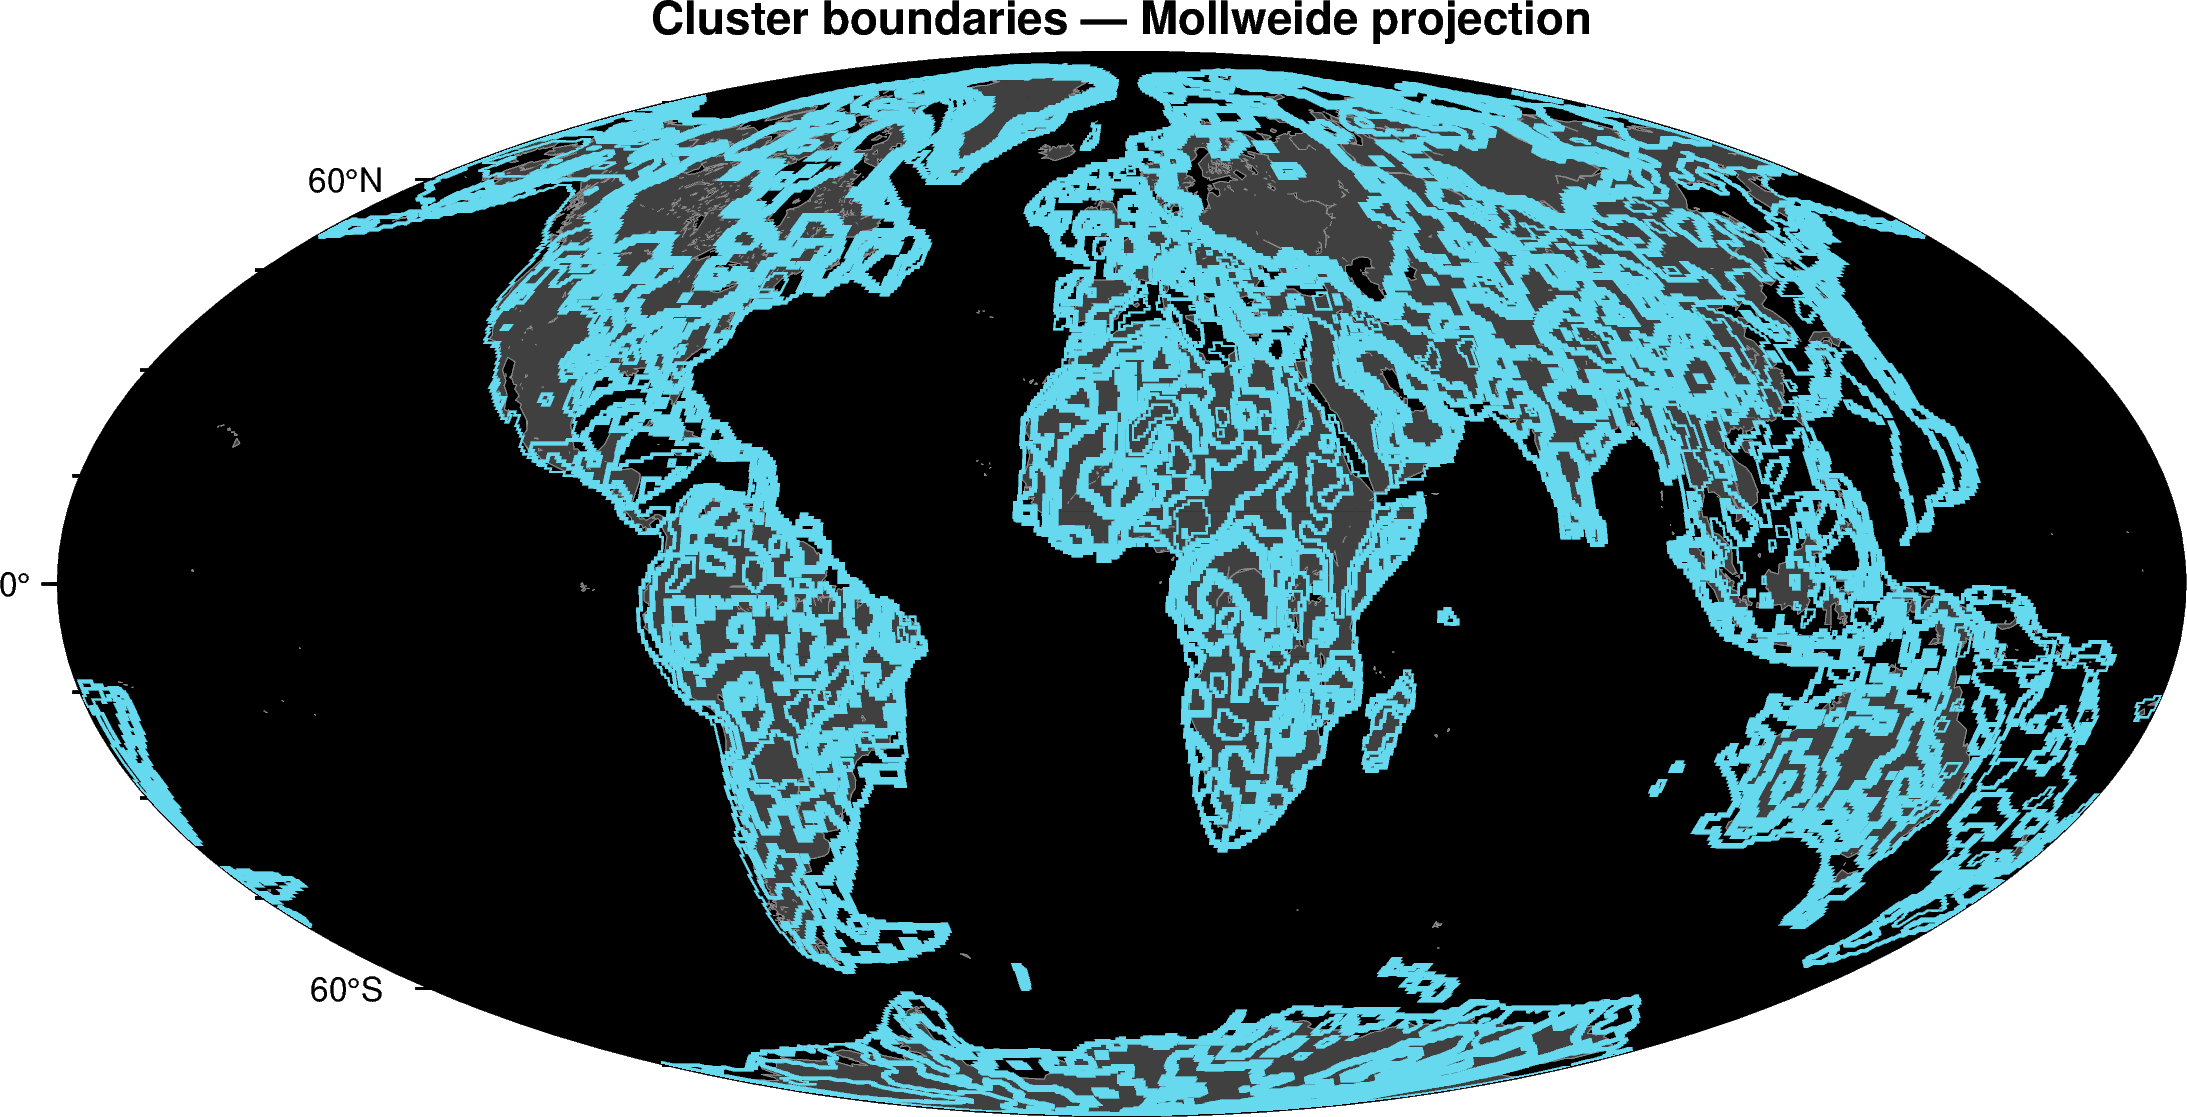

In [14]:
# §12 — Mollweide-projection map, boundary lines only. pyGMT handles the
# Mollweide projection natively via 'W<lon0>/<width>' — no manual pyproj warp needed.
fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/18c", frame="afg")
fig.coast(region="d", projection="W0/18c", land="gray25", water="black",
          shorelines="0.15p,gray55")
for rank in range(1, N_CLUSTERS + 1):
    sub = boundaries_gdf[boundaries_gdf["ClusterOrdered"] == rank]
    if len(sub) == 0: continue
    pen = f"{boundary_pen_pt(rank):.2f}p,#66d9ef"
    for geom in sub.geometry:
        if geom is None or geom.is_empty: continue
        parts = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
        for part in parts:
            xs, ys = zip(*list(part.coords))
            fig.plot(x=list(xs), y=list(ys), pen=pen, region="d", projection="W0/18c")
fig.text(text="Cluster boundaries — Mollweide projection",
         position="TC", offset="0/0.3c", justify="MC",
         font="11p,Helvetica-Bold,black", no_clip=True,
         region="d", projection="W0/18c")
fig.show(width=1100)


### How to read the Mollweide boundaries-only map

Same cluster boundaries as §11 but in an equal-area Mollweide projection. Useful for comparing boundary lengths between continents fairly — cyan lines that look short in Mercator can be very long in Mollweide, and vice versa. Deposits are omitted here on purpose so the boundary geometry can be read cleanly.


## 13. Filled cluster map — colored by VSH value range, clipped to continents

This is the headline map: each cluster is filled with its own **semi-transparent** color
(`CLUSTER_FILL_ALPHA`, Config cell) using a continuous **blue (low VSH) → red (high VSH)**
colormap (5 distinct hues: blue → teal → green → orange → red, `CLUSTER_CMAP_NAME`), labeled by its
mean-VSH range in the legend (`Cluster No: Min–Max`, km/s) — or by the fixed `VSH_BIN_EDGES` values
when `USE_FIXED_VSH_BINS = True`. It's built from `cluster_polygons_gdf` (Section 8), so it only
covers land if `CLIP_TO_CONTINENTS = True`.

Set `USE_SATELLITE_BASEMAP = True` in the Config cell for a real satellite ("Google Earth style")
image behind the map — fetched the same way as Section 11 (Esri World Imagery via `contextily`,
which needs internet access), then reprojected into this map's Mollweide projection with
`contextily.warp_tiles` (rasterio-based, robust for arbitrary projections — unlike trying to warp
map tiles live inside a `cartopy` GeoAxes, which is fragile for non-standard projections like
Mollweide and can silently render blank). Without internet access it falls back to a plain
ocean-tinted background.


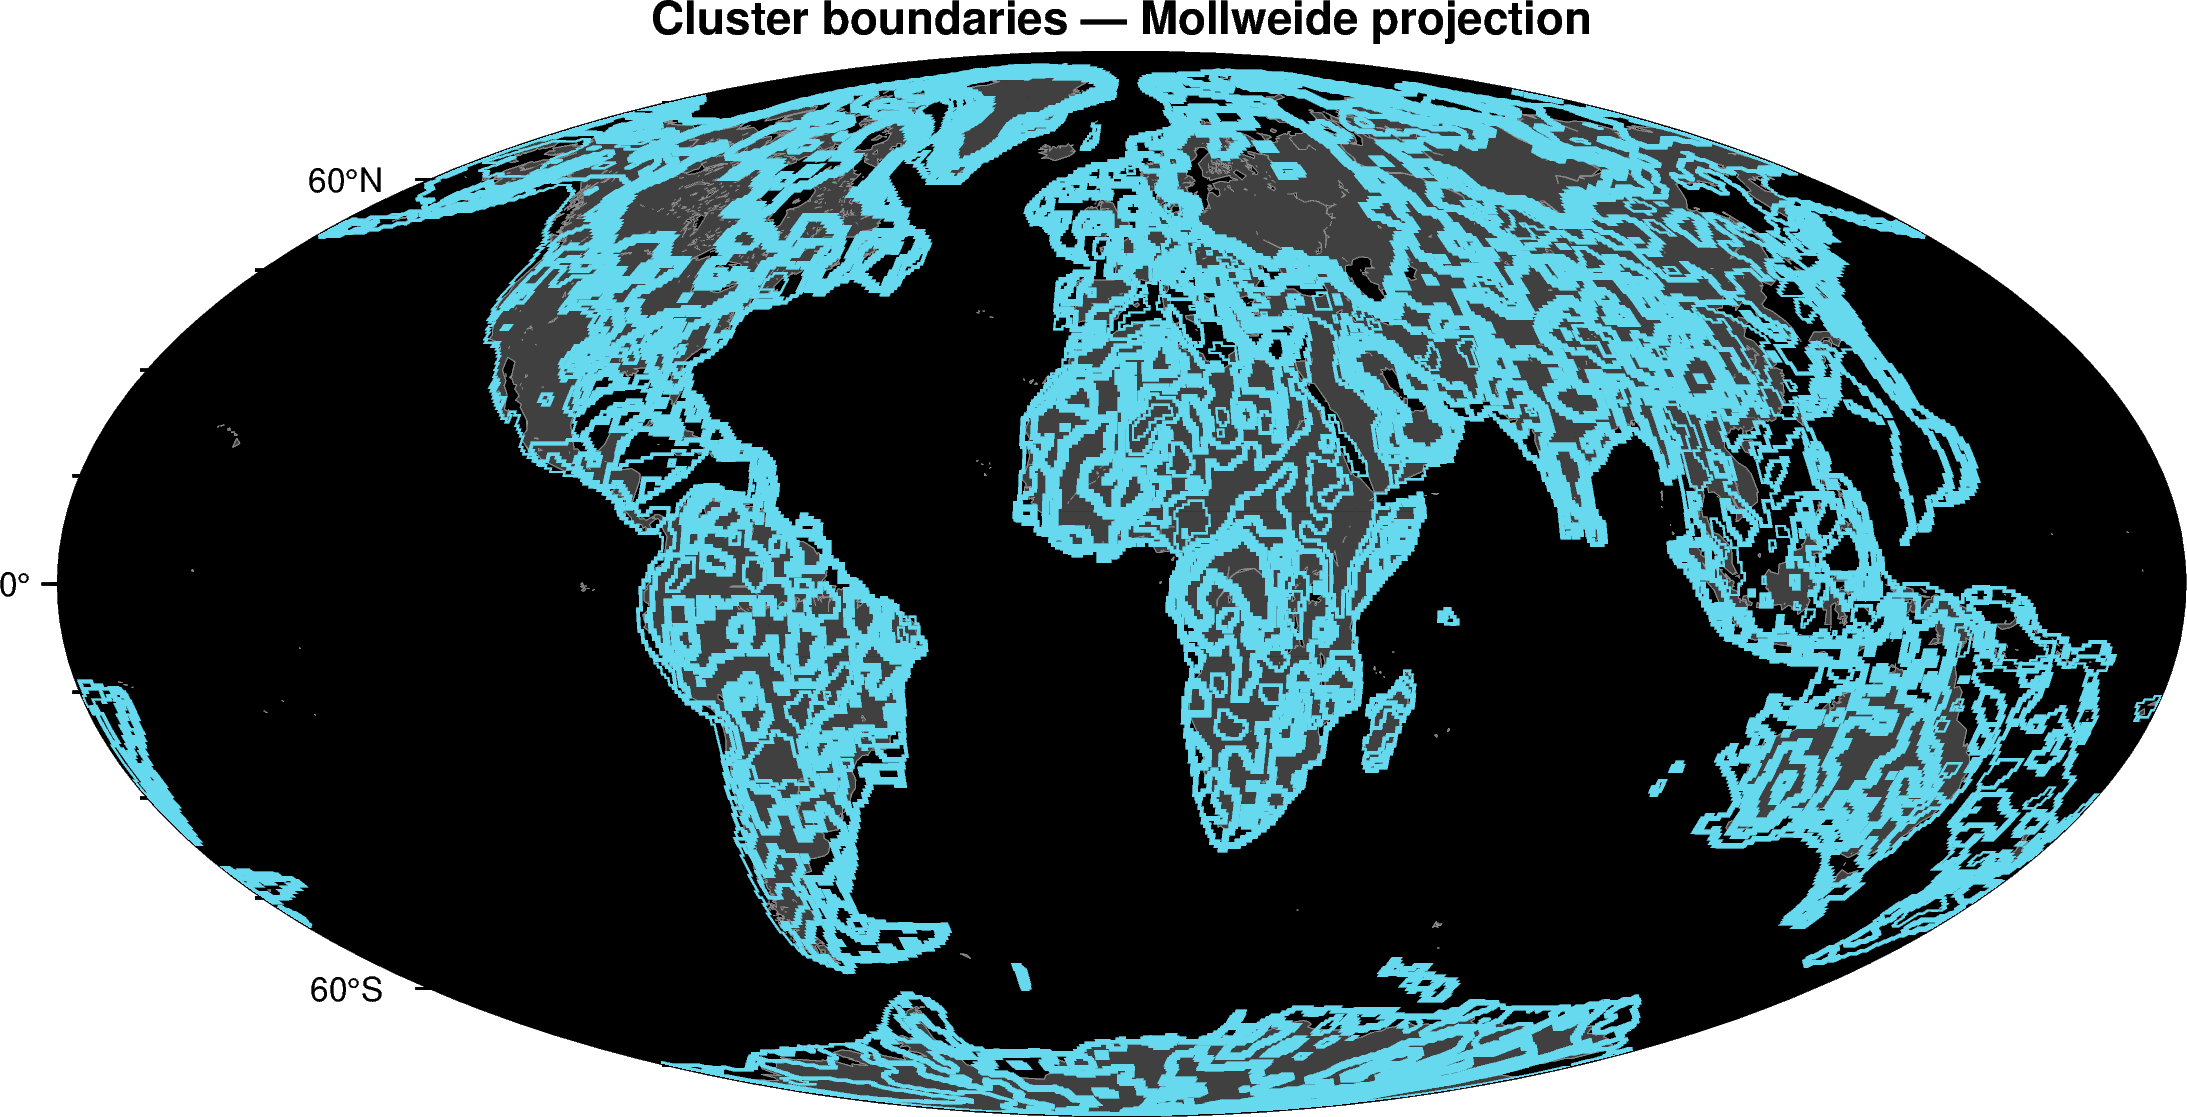

In [15]:
# §12 — Mollweide-projection map, boundary lines only. pyGMT handles the
# Mollweide projection natively via 'W<lon0>/<width>' — no manual pyproj warp needed.
fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/18c", frame="afg")
fig.coast(region="d", projection="W0/18c", land="gray25", water="black",
          shorelines="0.15p,gray55")
for rank in range(1, N_CLUSTERS + 1):
    sub = boundaries_gdf[boundaries_gdf["ClusterOrdered"] == rank]
    if len(sub) == 0: continue
    pen = f"{boundary_pen_pt(rank):.2f}p,#66d9ef"
    for geom in sub.geometry:
        if geom is None or geom.is_empty: continue
        parts = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
        for part in parts:
            xs, ys = zip(*list(part.coords))
            fig.plot(x=list(xs), y=list(ys), pen=pen, region="d", projection="W0/18c")
fig.text(text="Cluster boundaries — Mollweide projection",
         position="TC", offset="0/0.3c", justify="MC",
         font="11p,Helvetica-Bold,black", no_clip=True,
         region="d", projection="W0/18c")
fig.show(width=1100)


## 14. Map — target cluster boundary only

Isolates just **Cluster `TARGET_CLUSTER_RANK`** (set in the Config cell; 1 = lowest mean VSH,
`N_CLUSTERS` = highest) so its shape and extent are easy to read on their own, without the other
clusters cluttering the map. The cluster's **interior is filled** (semi-transparent) so inside vs.
outside of the boundary is visually obvious, not just the outline. Deposits are overlaid for
context — color = Type, size = Ore Tonnage, same scheme as the other maps.


Cluster 4 boundary: 136 line segments, mean VSH range 4.58-4.68 km/s


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


legend [WARNING]: File <stdin> is empty!


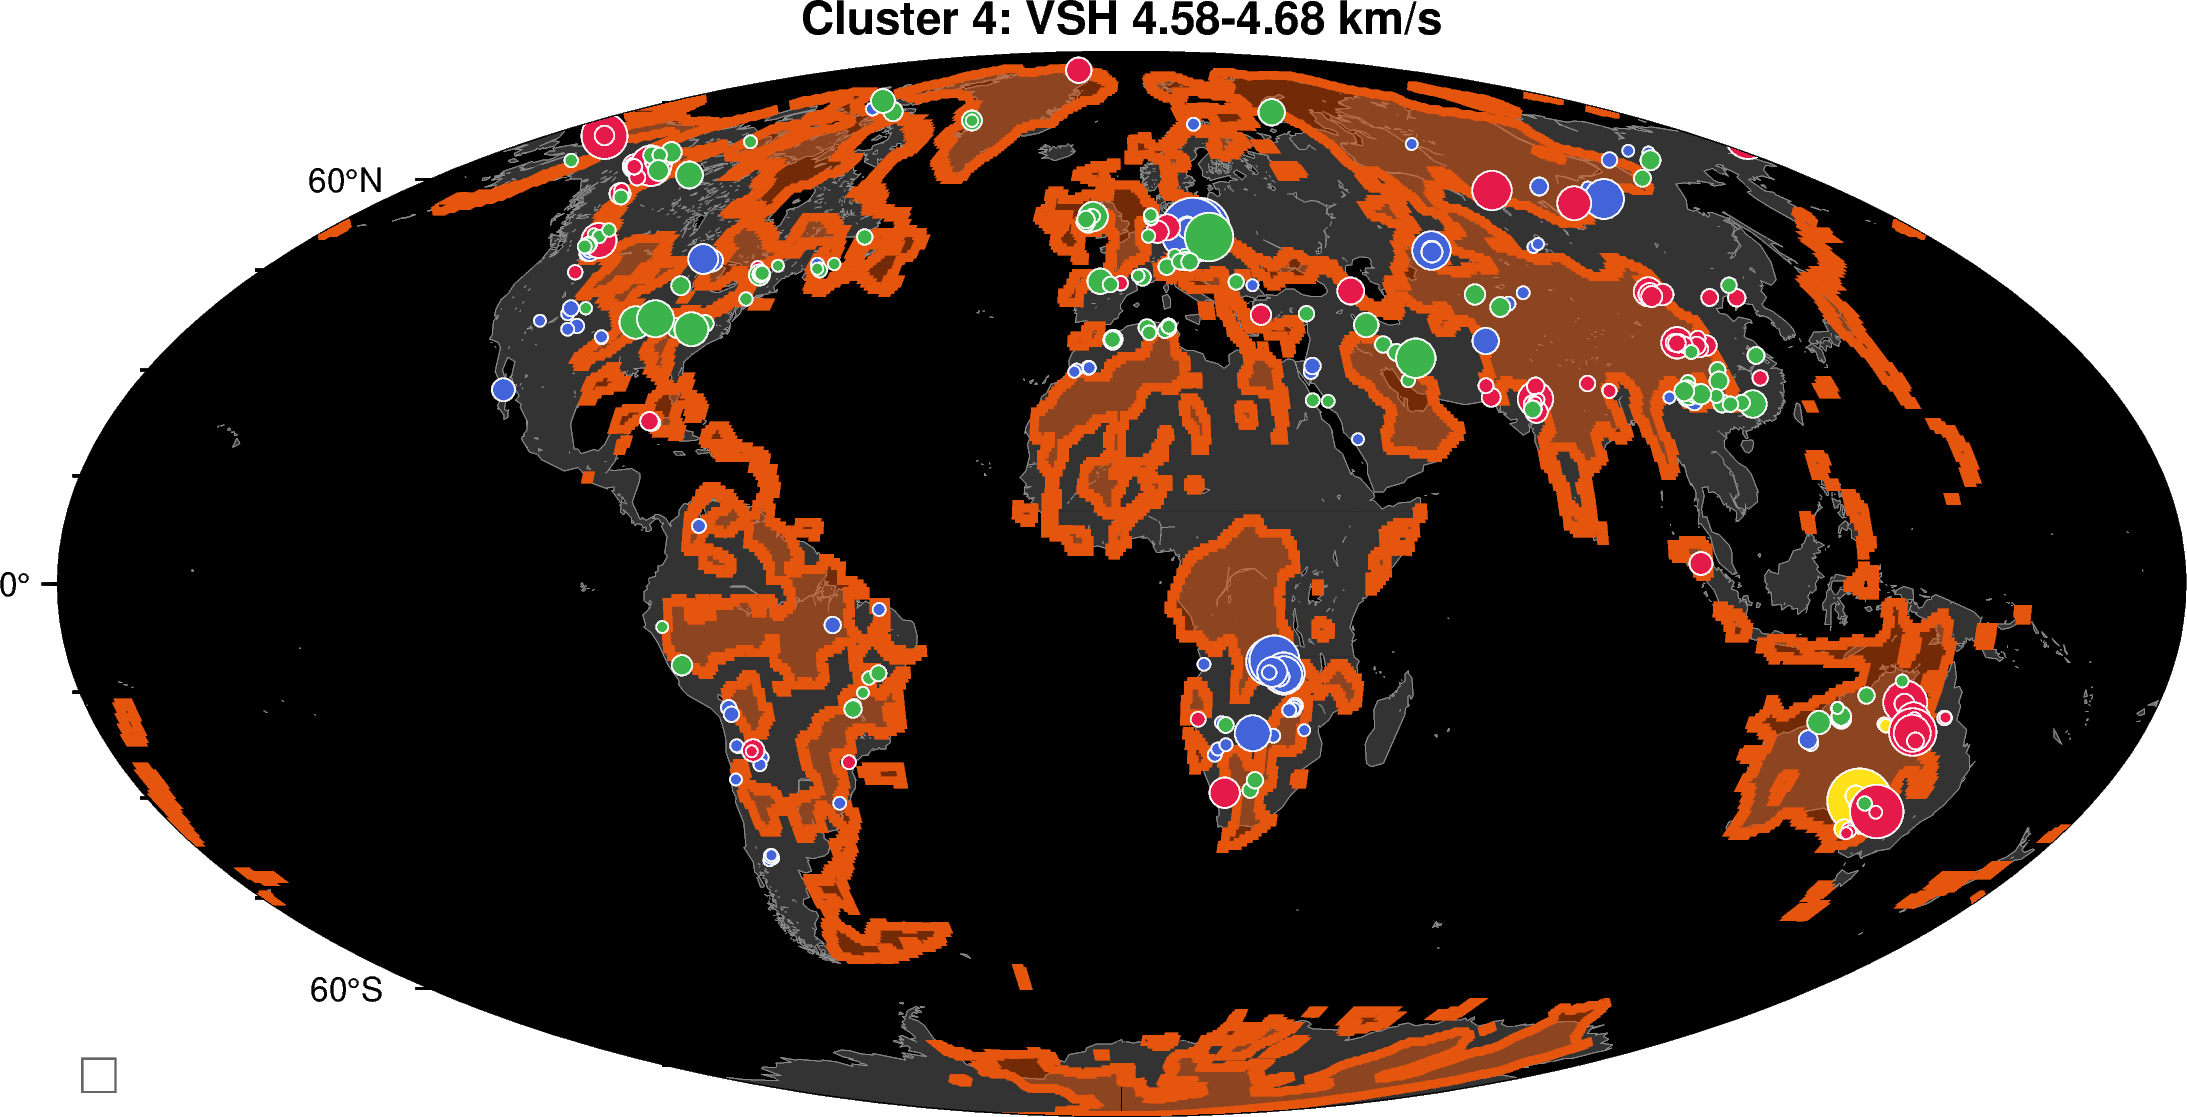

In [16]:
# §14 — Target cluster only: fill the target cluster's polygon(s), draw its boundary,
# overlay deposits. HIGHEST_CLUSTER_RANK is set from TARGET_CLUSTER_RANK in the CONFIG.
HIGHEST_CLUSTER_RANK = TARGET_CLUSTER_RANK
highest_boundary_gdf = boundaries_gdf[boundaries_gdf["ClusterOrdered"] == HIGHEST_CLUSTER_RANK].reset_index(drop=True)
highest_fill_gdf     = cluster_polygons_gdf[cluster_polygons_gdf["ClusterOrdered"] == HIGHEST_CLUSTER_RANK].reset_index(drop=True)
highest_fill_union   = highest_fill_gdf.geometry.union_all()  # used in Section 15 for inside/outside test
print(f"Cluster {HIGHEST_CLUSTER_RANK} boundary: {len(highest_boundary_gdf)} line segments, "
      f"mean VSH range {cluster_vsh_stats_ordered.loc[HIGHEST_CLUSTER_RANK,'min']:.2f}"
      f"-{cluster_vsh_stats_ordered.loc[HIGHEST_CLUSTER_RANK,'max']:.2f} km/s")

fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/18c", frame="afg")
fig.coast(region="d", projection="W0/18c", land="gray20", water="black",
          shorelines="0.15p,gray55")

target_colour = CLUSTER_PALETTE[HIGHEST_CLUSTER_RANK - 1]

# Fill target cluster polygons
for geom in highest_fill_gdf.geometry:
    if geom is None or geom.is_empty: continue
    parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for part in parts:
        xs, ys = zip(*list(part.exterior.coords))
        fig.plot(x=list(xs), y=list(ys), close=True,
                 fill=f"{target_colour}@50", pen="0p,black",
                 region="d", projection="W0/18c")
# Boundary polylines on top
for geom in highest_boundary_gdf.geometry:
    if geom is None or geom.is_empty: continue
    parts = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
    for part in parts:
        xs, ys = zip(*list(part.coords))
        fig.plot(x=list(xs), y=list(ys), pen=f"2p,{target_colour}",
                 region="d", projection="W0/18c")

for t in deposit_types:
    sub = deposits_gdf[deposits_gdf[TYPE_FIELD] == t]
    if len(sub) == 0: continue
    fig.plot(x=sub.geometry.x, y=sub.geometry.y,
             style="cc", size=sub["marker_size_cm"].values,
             fill=TYPE_COLORS[t], pen="0.3p,white",
             region="d", projection="W0/18c", label=t)

fig.text(text=(f"Cluster {HIGHEST_CLUSTER_RANK}: VSH "
               f"{cluster_vsh_stats_ordered.loc[HIGHEST_CLUSTER_RANK,'min']:.2f}"
               f"-{cluster_vsh_stats_ordered.loc[HIGHEST_CLUSTER_RANK,'max']:.2f} km/s"),
         position="TC", offset="0/0.3c", justify="MC",
         font="11p,Helvetica-Bold,black", no_clip=True,
         region="d", projection="W0/18c")
fig.legend(position="JBL+jBL+o0.2c/0.2c", box="+gwhite+p0.4p,gray40")
fig.show(width=1100)


### How to read the target-cluster-only map

The `TARGET_CLUSTER_RANK` in the CONFIG cell (default = the top-ranked, highest-VSH cluster) is isolated. Filled polygons = *inside* the target cluster; the plain black background = *outside*. Set `TARGET_CLUSTER_RANK = 1` to see the lowest-VSH class instead. This is the same target cluster whose boundary drives the inside/outside distance calculation in §15.


## 15. Deposit → nearest *target-cluster* boundary distance (signed: inside vs. outside)

Same geodesic KD-tree approach as Section 10, but restricted to only the boundary segments of the
single target cluster isolated above. `Dist_to_HighestCluster_km` is **signed**: negative if the
deposit falls *inside* Cluster `TARGET_CLUSTER_RANK`'s region, positive if *outside* it — so the
sign alone tells you which side of the boundary a deposit is on, and the magnitude is still the
geodesic distance to the nearest point on that boundary.


In [17]:
highest_boundary_coords = []
for geom in highest_boundary_gdf.geometry:
    geoms = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
    for g in geoms:
        highest_boundary_coords.extend(list(g.coords))
highest_boundary_coords = np.array(highest_boundary_coords)

hbx, hby, hbz = to_ecef(highest_boundary_coords[:, 0], highest_boundary_coords[:, 1])
highest_boundary_tree = cKDTree(np.column_stack([hbx, hby, hbz]))

chord_dist_h, _ = highest_boundary_tree.query(np.column_stack([px, py, pz]), k=1)
unsigned_dist_h = 2 * EARTH_RADIUS_KM * np.arcsin(np.clip(chord_dist_h / (2 * EARTH_RADIUS_KM), 0, 1))

# Inside/outside test against the target cluster's actual polygon (not just nearest-boundary-point),
# so the sign is correct even where the boundary has multiple disjoint pieces.
is_inside = deposits_gdf.geometry.within(highest_fill_union)
deposits_gdf["Inside_TargetCluster"] = is_inside
deposits_gdf["Dist_to_HighestCluster_km"] = np.where(is_inside, -unsigned_dist_h, unsigned_dist_h)
deposits_gdf.to_file(deposits_out_path)  # re-save so the shapefile also carries this new distance field

print(f"Deposits inside Cluster {HIGHEST_CLUSTER_RANK}: {is_inside.sum()} / {len(deposits_gdf)}")
deposits_gdf[["Deposit", TYPE_FIELD, "Tonnage", "Dist_to_Boundary_km",
              "Inside_TargetCluster", "Dist_to_HighestCluster_km"]].describe(include="all")


Deposits inside Cluster 4: 125 / 420


/tmp/ipykernel_18541/2894107908.py:19: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Dist_to_Boundary_km' to 'Dist_to_Bo'
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'marker_size_cm' to 'marker_siz'
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Inside_TargetCluster' to 'Inside_Tar'
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Dist_to_HighestCluster_km' to 'Dist_to_Hi'


,Deposit,Type,Tonnage,Dist_to_Boundary_km,Inside_TargetCluster,Dist_to_HighestCluster_km
count,420,420,420.000000,4.200000e+02,420,420.000000
unique,418,4,NaN,NaN,2,NaN
top,Broken Hill,PbZn-MVT,NaN,NaN,False,NaN
freq,2,147,NaN,NaN,295,NaN
mean,NaN,NaN,3.325738,6.184991e+01,NaN,81.430798
std,NaN,NaN,9.415945,4.887816e+01,NaN,218.807976
min,NaN,NaN,0.000000,7.503331e-12,NaN,-736.726592
25%,NaN,NaN,0.107500,2.785552e+01,NaN,-33.044557
50%,NaN,NaN,0.500000,4.596496e+01,NaN,72.400168
75%,NaN,NaN,2.002500,8.310403e+01,NaN,185.344980


## 16. Ore-Tonnage-weighted CDF — all deposits combined

Deposits are sorted by distance to the nearest boundary of *any* cluster, and the y-axis is the
**cumulative % of total ore tonnage** captured within that distance — i.e. "how close to a
boundary do you need to search to capture X% of known ore tonnage?"


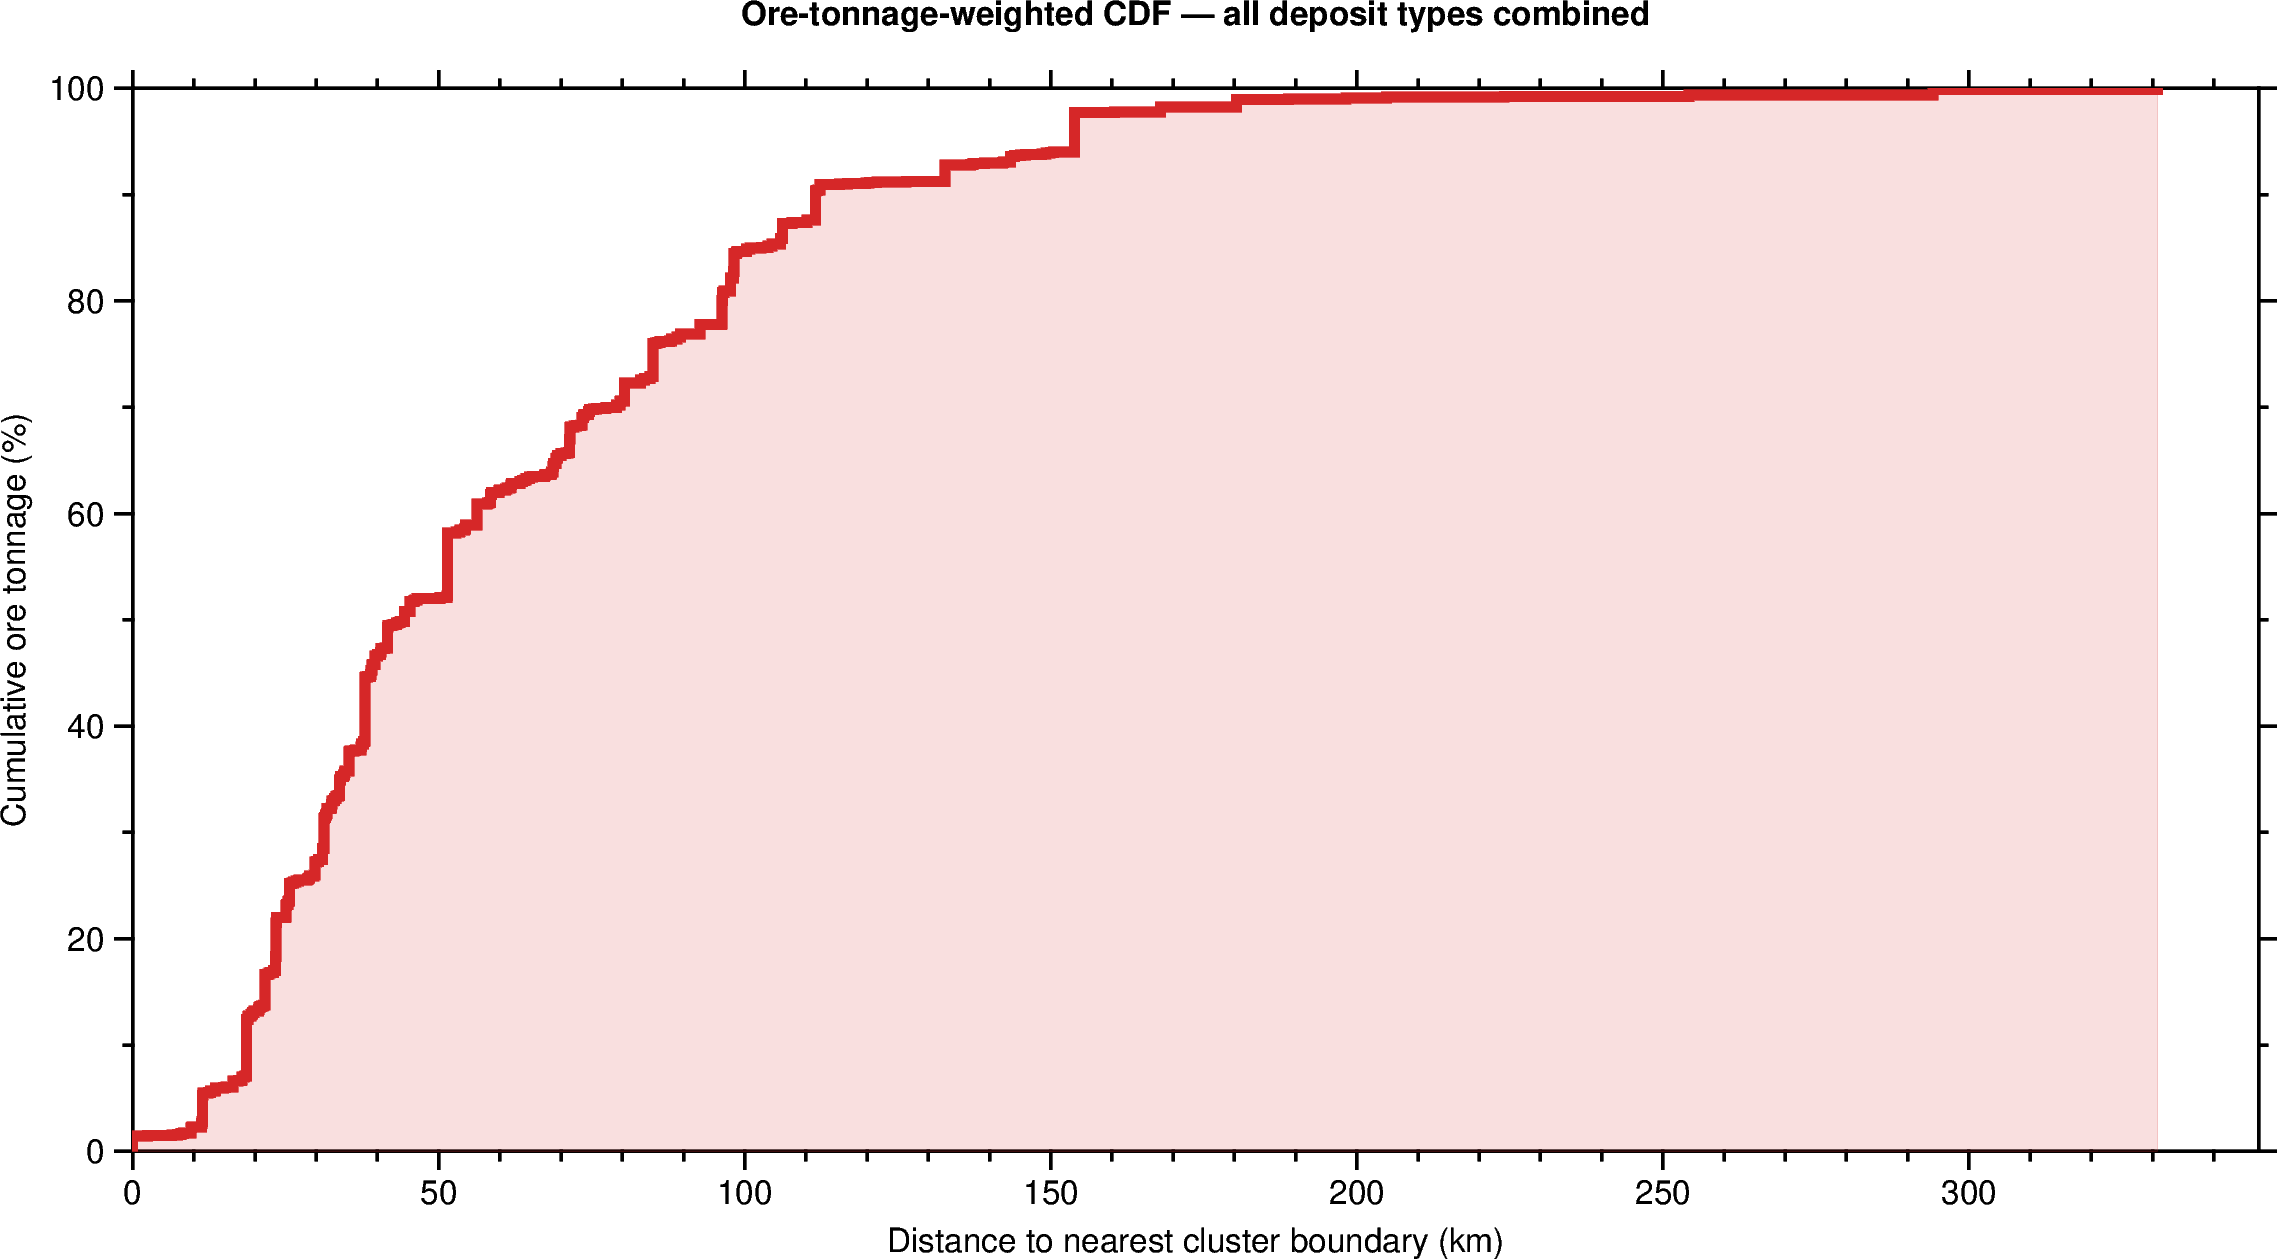

Saved: Notebooks/T72_cbf_outputs/weighted_CDF_all_deposits.png


In [18]:
# Weighted CDF helper (unchanged) + a small utility to make a pyGMT-friendly step-post
# polyline: duplicate every x with its pre/post y so fig.plot draws a proper stepped curve.
def weighted_cdf(df, dist_col="Dist_to_Boundary_km", weight_col="Tonnage"):
    d = df.dropna(subset=[dist_col]).copy()
    d = d[d[weight_col] > 0]
    d = d.sort_values(dist_col)
    cum_w = np.cumsum(d[weight_col].values)
    if len(cum_w) == 0 or cum_w[-1] == 0:
        return np.array([]), np.array([])
    cdf_pct = cum_w / cum_w[-1] * 100
    return d[dist_col].values, cdf_pct

def step_post_xy(x, y):
    """Turn (x_i, y_i) into stepped-post coords: draw horizontally, then jump vertically at x_i."""
    x_s, y_s = [], []
    if len(x) == 0: return np.array([]), np.array([])
    x_s.append(x[0]); y_s.append(0)
    for xi, yi in zip(x, y):
        x_s.append(xi); y_s.append(y_s[-1])
        x_s.append(xi); y_s.append(yi)
    return np.array(x_s), np.array(y_s)

# §16 — combined weighted CDF as a single pyGMT line
dist_all, cdf_all = weighted_cdf(deposits_gdf)
xs, ys = step_post_xy(dist_all, cdf_all)

fig = pygmt.Figure()
X_MAX = float(np.nanmax(dist_all)) * 1.05 if len(dist_all) else 1
fig.basemap(region=[0, X_MAX, 0, 100], projection="X18c/9c",
            frame=["WSne+tOre-tonnage-weighted CDF — all deposit types combined",
                   "xaf+lDistance to nearest cluster boundary (km)",
                   "yaf+lCumulative ore tonnage (%)"])
if len(xs):
    fig.plot(x=xs, y=ys, pen="2.5p,#d62728")
    # Simple fill: draw a closed polygon (curve down to y=0 on right, back to start)
    xs_fill = np.concatenate([xs, [xs[-1], xs[0]]])
    ys_fill = np.concatenate([ys, [0, 0]])
    fig.plot(x=xs_fill, y=ys_fill, close=False, fill="#d62728@85", pen="0.1p,#d62728@80")
fig.show(width=1000)

cdf_all_path = os.path.join(OUTPUT_DIR, "weighted_CDF_all_deposits.png")
fig.savefig(cdf_all_path)
print("Saved:", cdf_all_path)


### How to read the combined CDF

The x-axis is distance-to-nearest-cluster-boundary in km. The y-axis is cumulative ore tonnage as a percent of the global total. A curve that rises steeply near x=0 means most of the global ore tonnage is concentrated within a small distance of a cluster boundary — i.e. mineral deposits are edge-huggers. A shallow curve means tonnage is distributed uniformly with respect to the boundary framework. A rule-of-thumb threshold: if ≥ 50 % of tonnage lies within \~200 km, the edge-hugging pattern is real.


## 17. Ore-Tonnage-weighted CDF — per deposit type

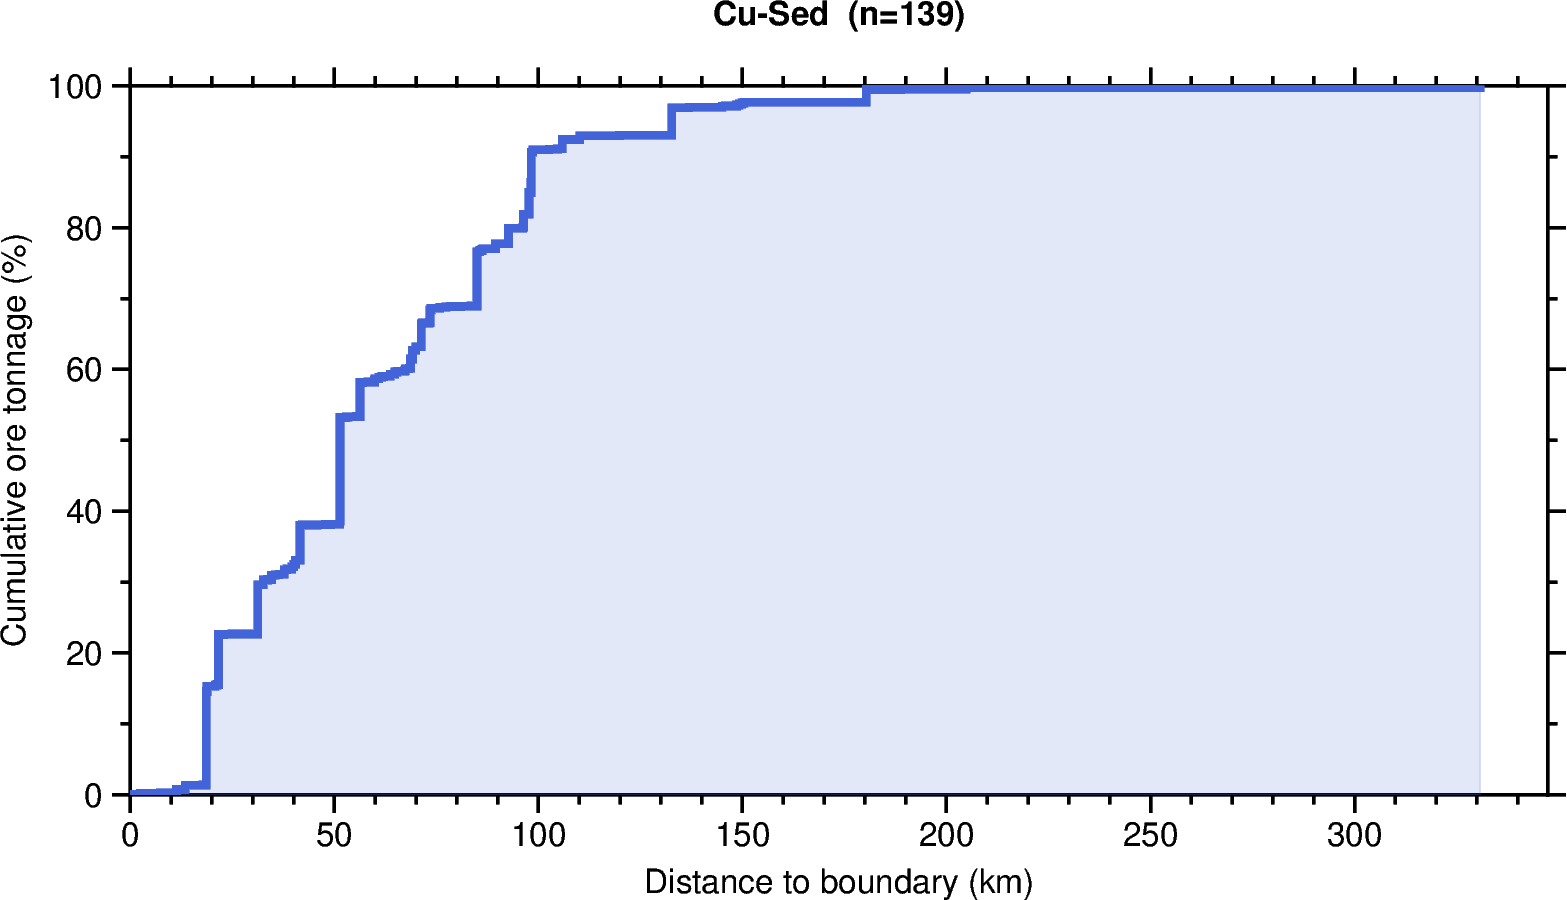

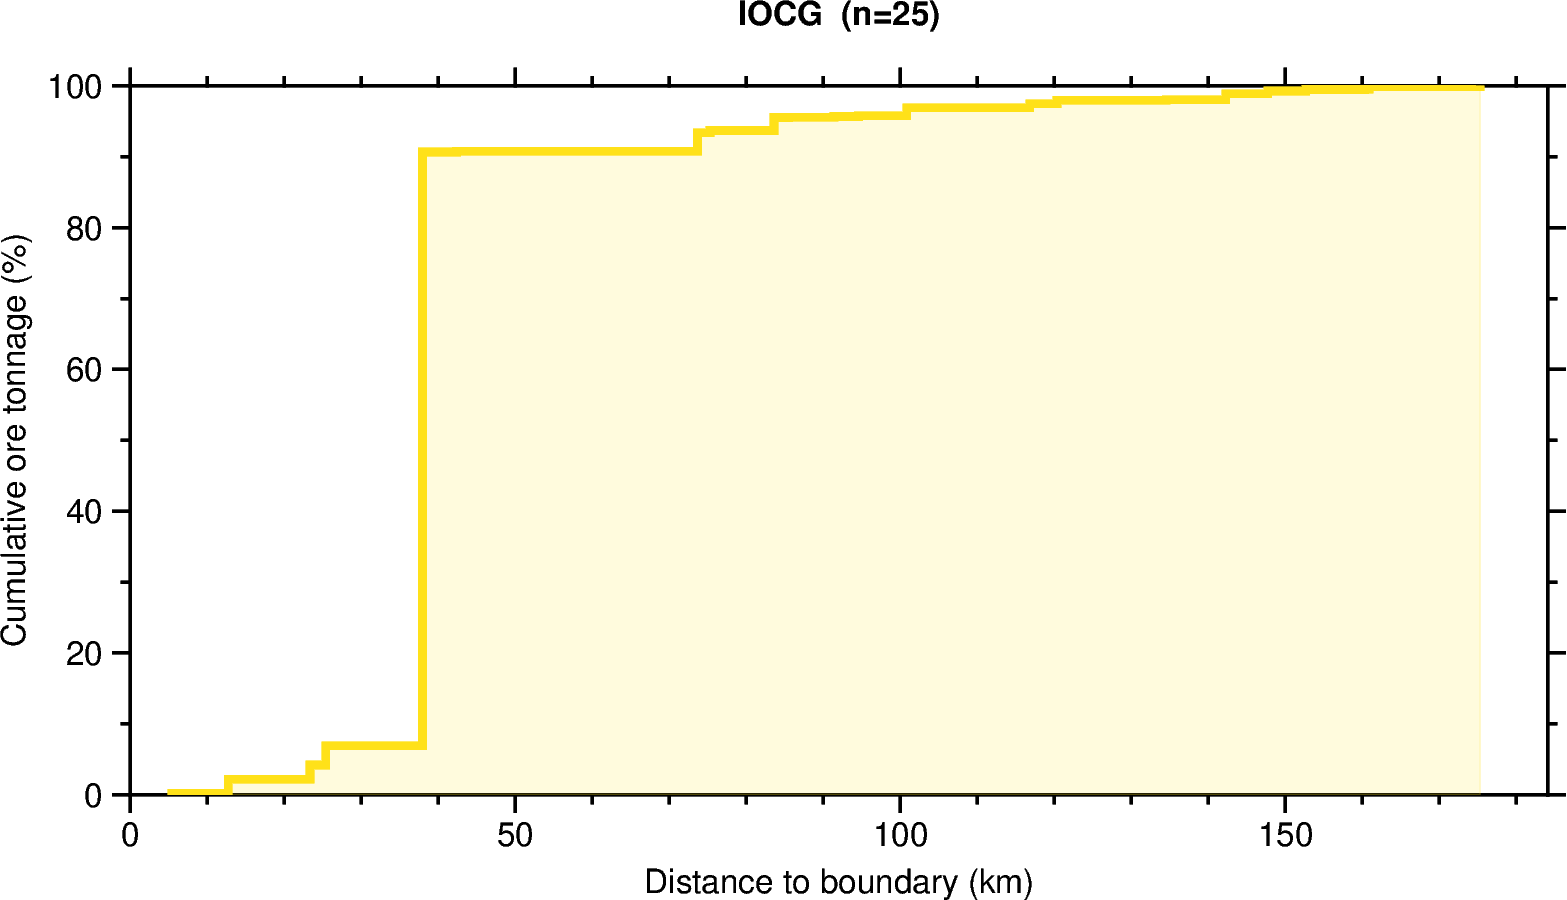

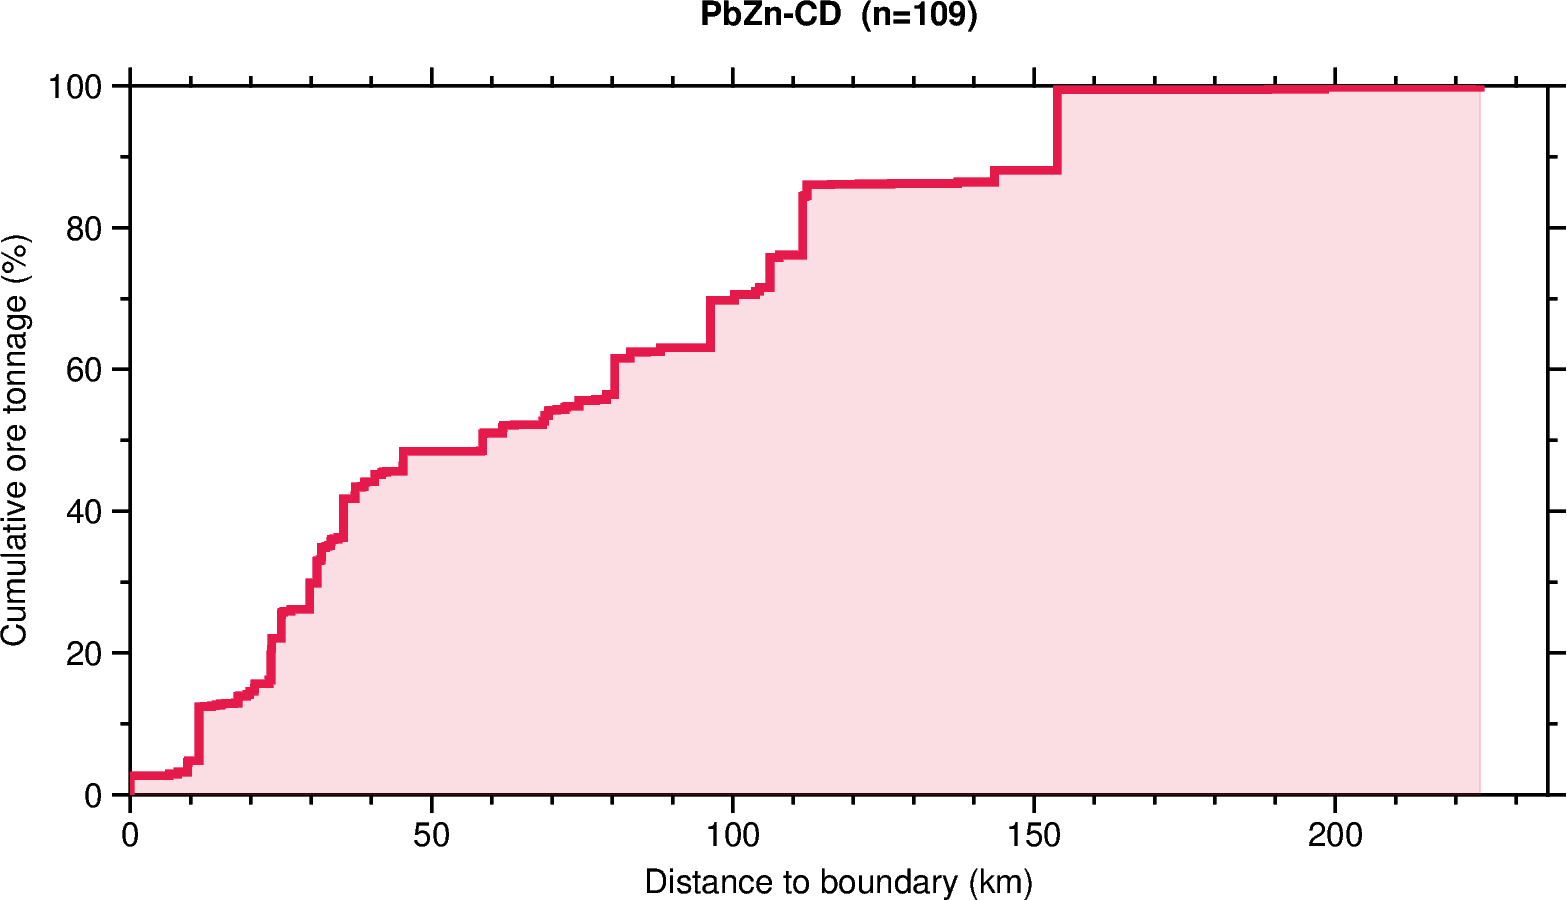

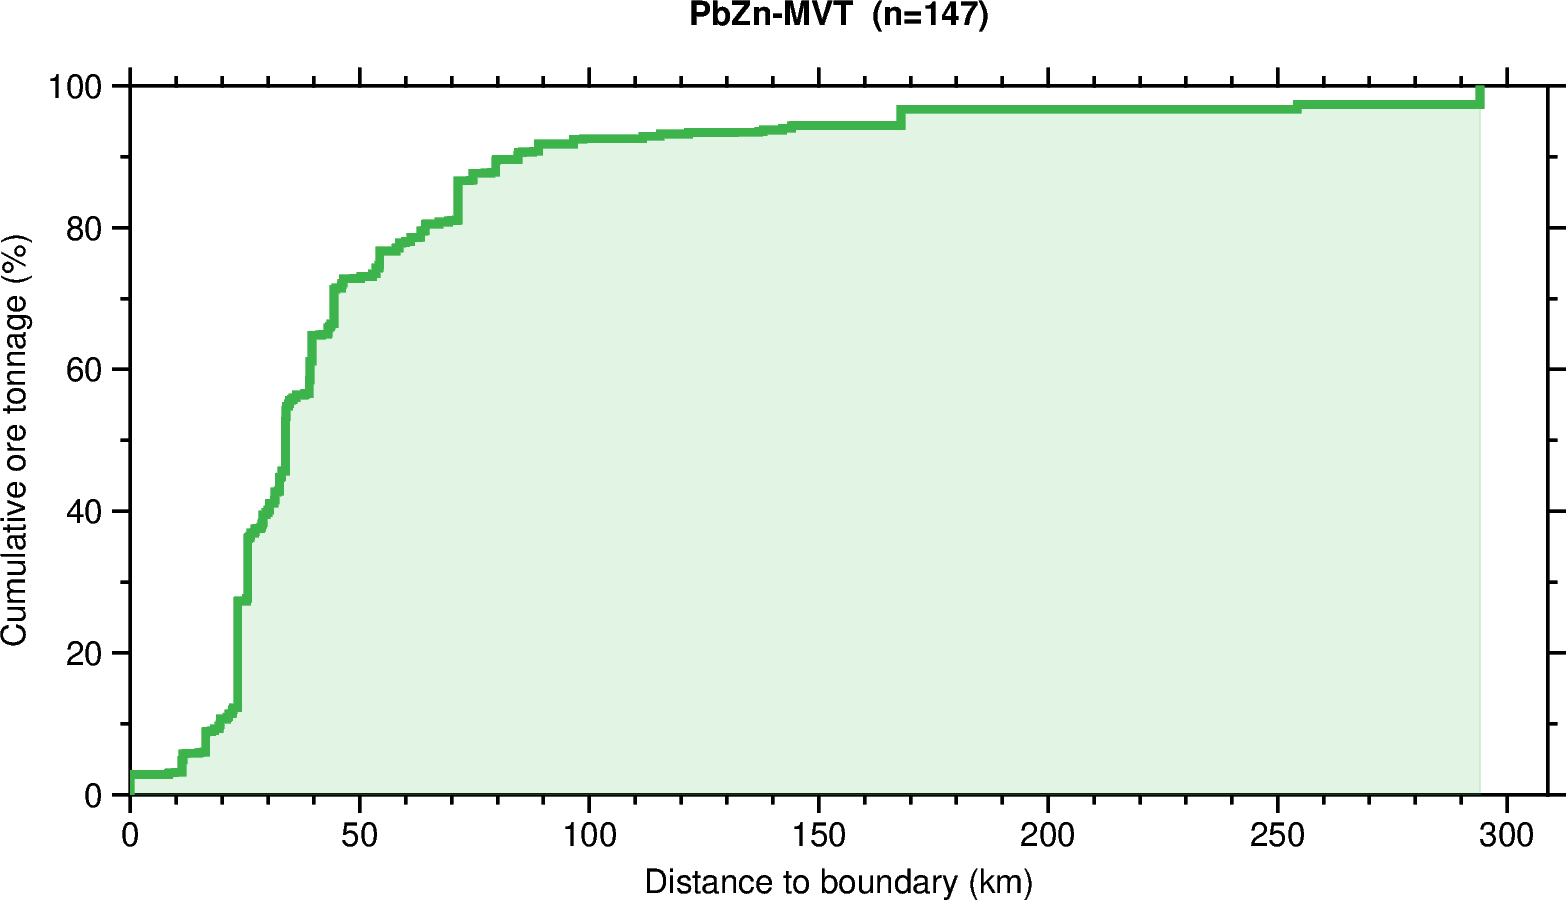

Per-type CDFs rendered; last figure also saved to: Notebooks/T72_cbf_outputs/weighted_CDF_by_type_last.png


In [19]:
# §17 — one small pyGMT figure per deposit type (house style: separate Figure per panel)
types_present = sorted(deposits_gdf[TYPE_FIELD].unique())

for t in types_present:
    subset = deposits_gdf[deposits_gdf[TYPE_FIELD] == t]
    dist_t, cdf_t = weighted_cdf(subset)
    xs, ys = step_post_xy(dist_t, cdf_t)
    colour = TYPE_COLORS.get(t, "blue")
    X_MAX = float(np.nanmax(dist_t)) * 1.05 if len(dist_t) else 1

    fig = pygmt.Figure()
    fig.basemap(region=[0, X_MAX, 0, 100], projection="X12c/6c",
                frame=["WSne+t" + f"{t}  (n={len(subset)})",
                       "xaf+lDistance to boundary (km)",
                       "yaf+lCumulative ore tonnage (%)"])
    if len(xs):
        fig.plot(x=xs, y=ys, pen=f"2p,{colour}")
        xs_fill = np.concatenate([xs, [xs[-1], xs[0]]])
        ys_fill = np.concatenate([ys, [0, 0]])
        fig.plot(x=xs_fill, y=ys_fill, close=False, fill=f"{colour}@85", pen=f"0.1p,{colour}@80")
    fig.show(width=750)

cdf_type_path = os.path.join(OUTPUT_DIR, "weighted_CDF_by_type_last.png")
print("Per-type CDFs rendered; last figure also saved to:", cdf_type_path)


### How to read the per-type CDFs

One panel per deposit type. Compare the steepness at small x to spot the strongest edge-huggers. Order of edge-preference varies by dataset but IOCG and Magmatic_Ni are typically the tightest; PbZn-MVT and Cu-Sed are typically the loosest.


## 18. Ore-Tonnage-weighted CDF — all types overlaid

One more CDF graph: every deposit type's weighted CDF drawn on the **same axes** for direct
comparison, plus the **combined all-deposits** curve from Section 12 overlaid as a bold dashed line.


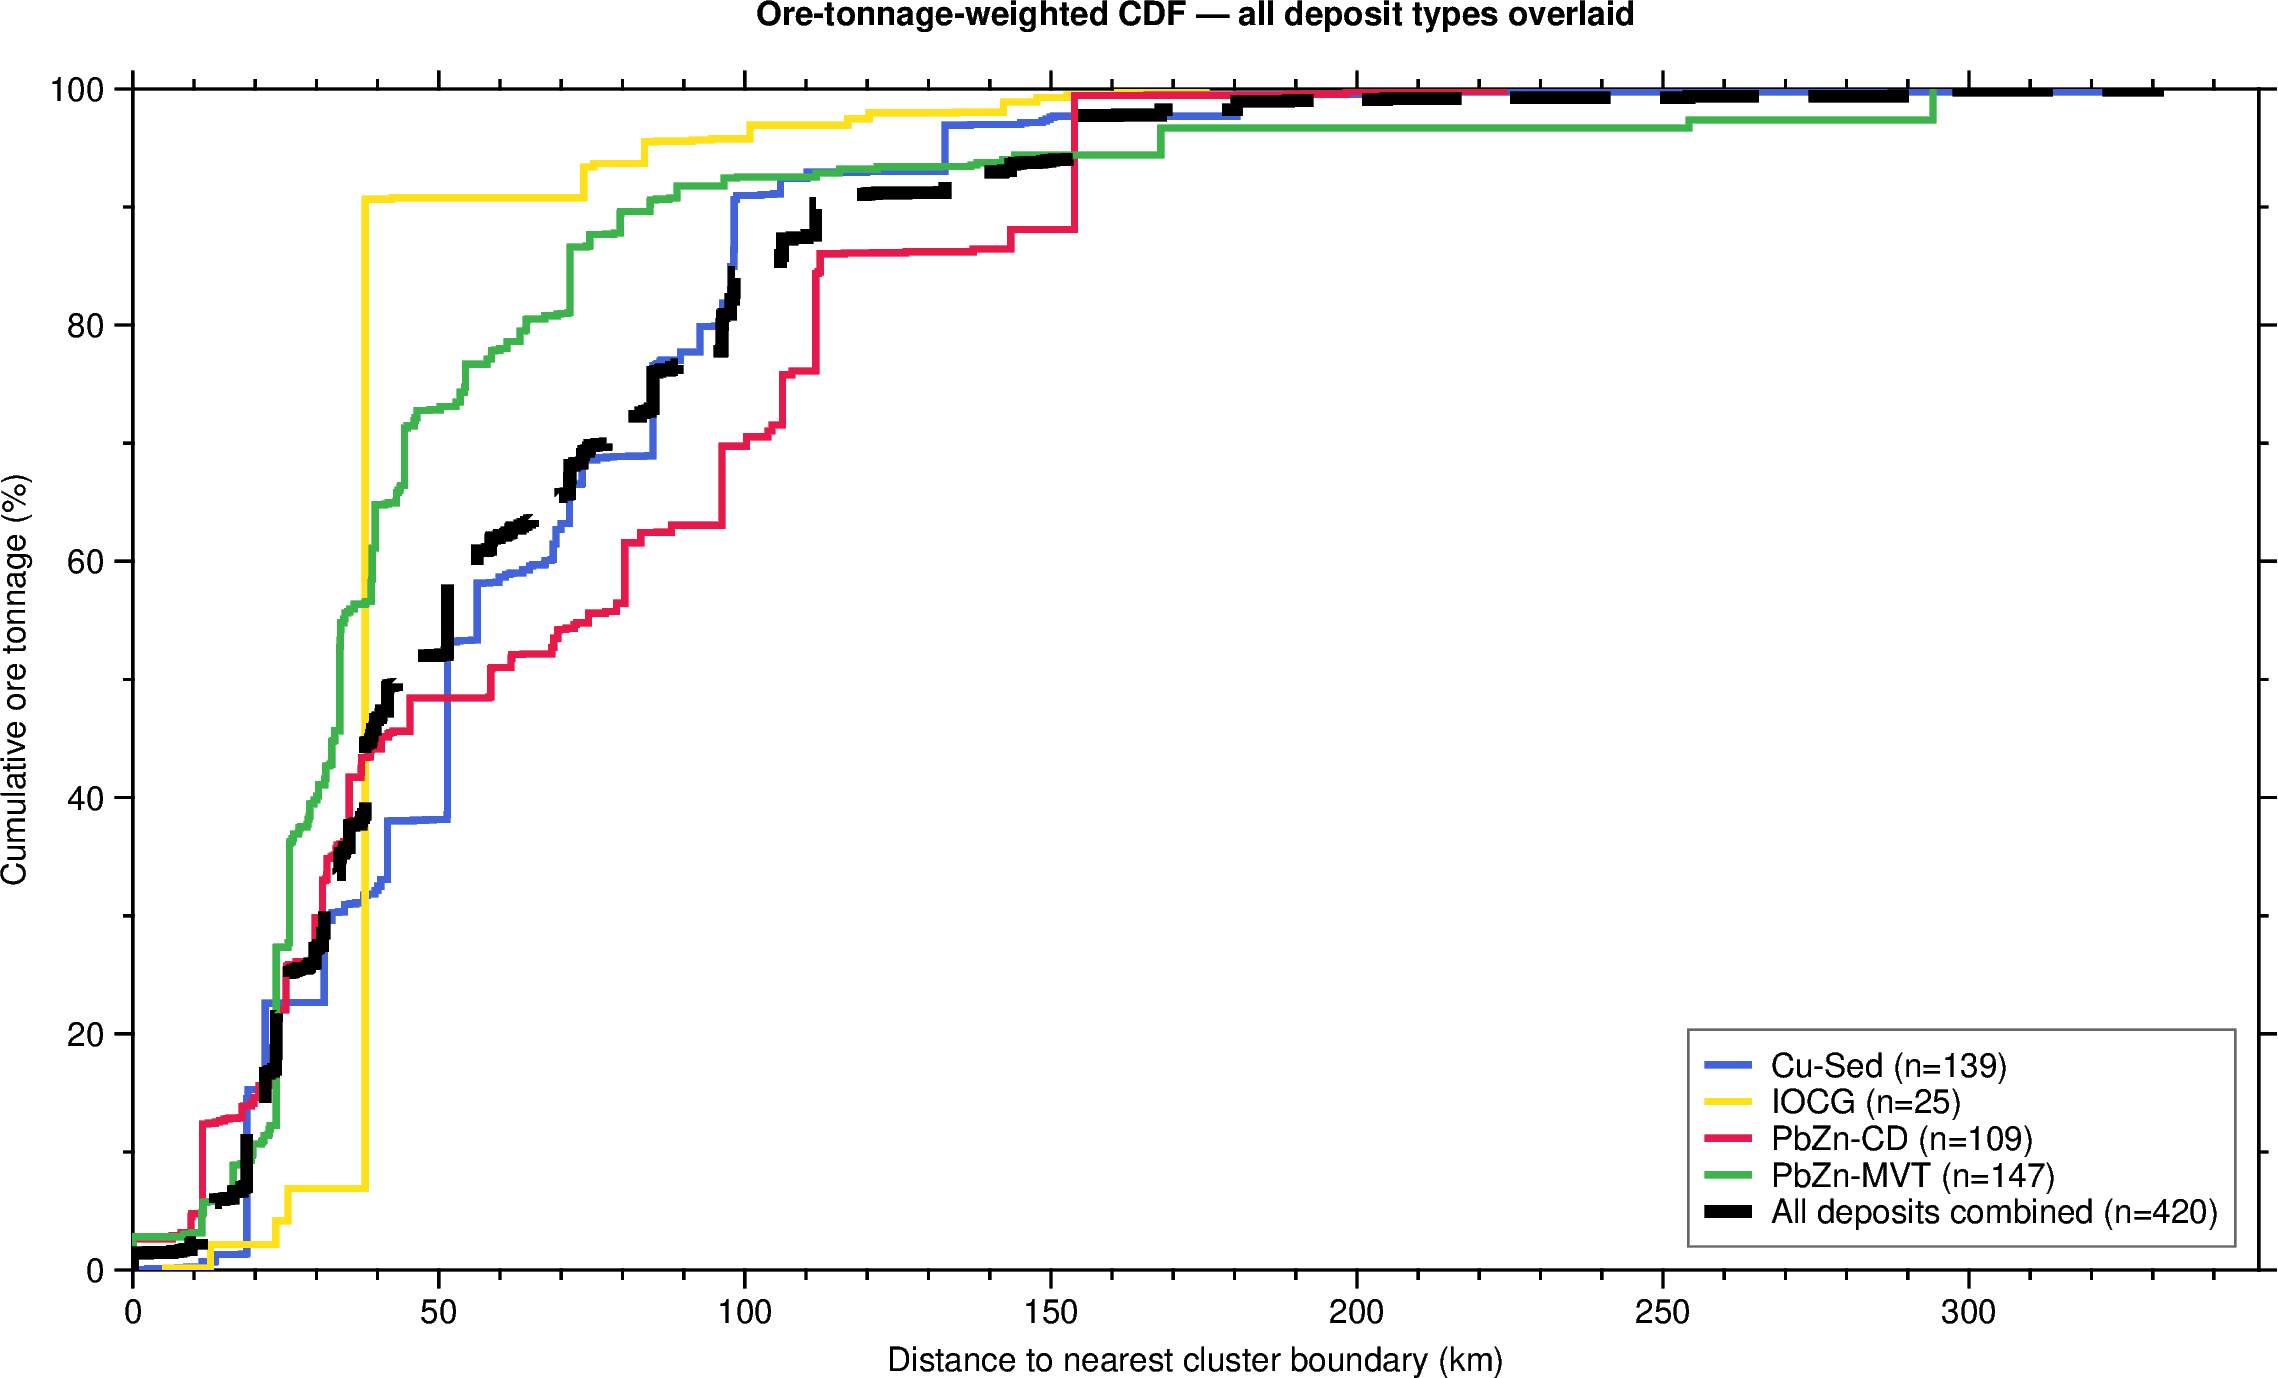

Saved: Notebooks/T72_cbf_outputs/weighted_CDF_overlay_by_type.png


In [20]:
# §18 — all deposit-type curves overlaid, plus the combined 'all' curve in bold
fig = pygmt.Figure()
X_MAX = float(np.nanmax(dist_all)) * 1.05 if len(dist_all) else 1
fig.basemap(region=[0, X_MAX, 0, 100], projection="X18c/10c",
            frame=["WSne+tOre-tonnage-weighted CDF — all deposit types overlaid",
                   "xaf+lDistance to nearest cluster boundary (km)",
                   "yaf+lCumulative ore tonnage (%)"])

for t in types_present:
    subset = deposits_gdf[deposits_gdf[TYPE_FIELD] == t]
    dist_t, cdf_t = weighted_cdf(subset)
    xs, ys = step_post_xy(dist_t, cdf_t)
    if len(xs) == 0: continue
    colour = TYPE_COLORS.get(t, "blue")
    fig.plot(x=xs, y=ys, pen=f"1.6p,{colour}", label=f"{t} (n={len(subset)})")

# combined "all deposits" curve on top, dashed thick black
xs_all, ys_all = step_post_xy(dist_all, cdf_all)
fig.plot(x=xs_all, y=ys_all, pen="3p,black,-",
         label=f"All deposits combined (n={len(deposits_gdf)})")

fig.legend(position="JBR+jBR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1000)

cdf_overlay_path = os.path.join(OUTPUT_DIR, "weighted_CDF_overlay_by_type.png")
print("Saved:", cdf_overlay_path)


### How to read the overlay CDF

All per-type curves + the combined 'All deposits' curve (bold dashed black). Curves lying to the LEFT of the combined curve are types that hug the boundaries MORE strongly than the population average; curves to the RIGHT are types that hug LESS strongly. This is the cleanest single-figure summary of which deposit type is most strongly localised by the craton-boundary framework.


## 19. Deposits on a paleogeographic reconstruction — GPlately reconstruction

Every notebook in this suite must include at least one reconstructed paleogeographic map (core-purpose rule, see CLAUDE.md). Here we take the deposits from `All_Deposits.shp` — which include a formation age in the `Age__Ga_` column — assign each a plate ID via **Cao 2024** static polygons (the 0-1.8 Ga plate model that matches the deep-time age range of the Precambrian deposits), reconstruct every deposit whose formation age falls in a chosen window to that window's centre, and overlay them on the paleogeographic reconstruction continents at that age.

The interpretation is: *where were mineral deposits formed geographically at time T*, and how does that map relate to the modern craton-boundary framework we built in §1-15 from present-day tomography?


  99 deposits with age 300-700 Ma
  99 deposits reconstructable to 500 Ma


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


plot [WARNING]: Cannot use auto-legend -l for variable symbol size unless +S<size> is used. Option -l ignored.


legend [WARNING]: File <stdin> is empty!


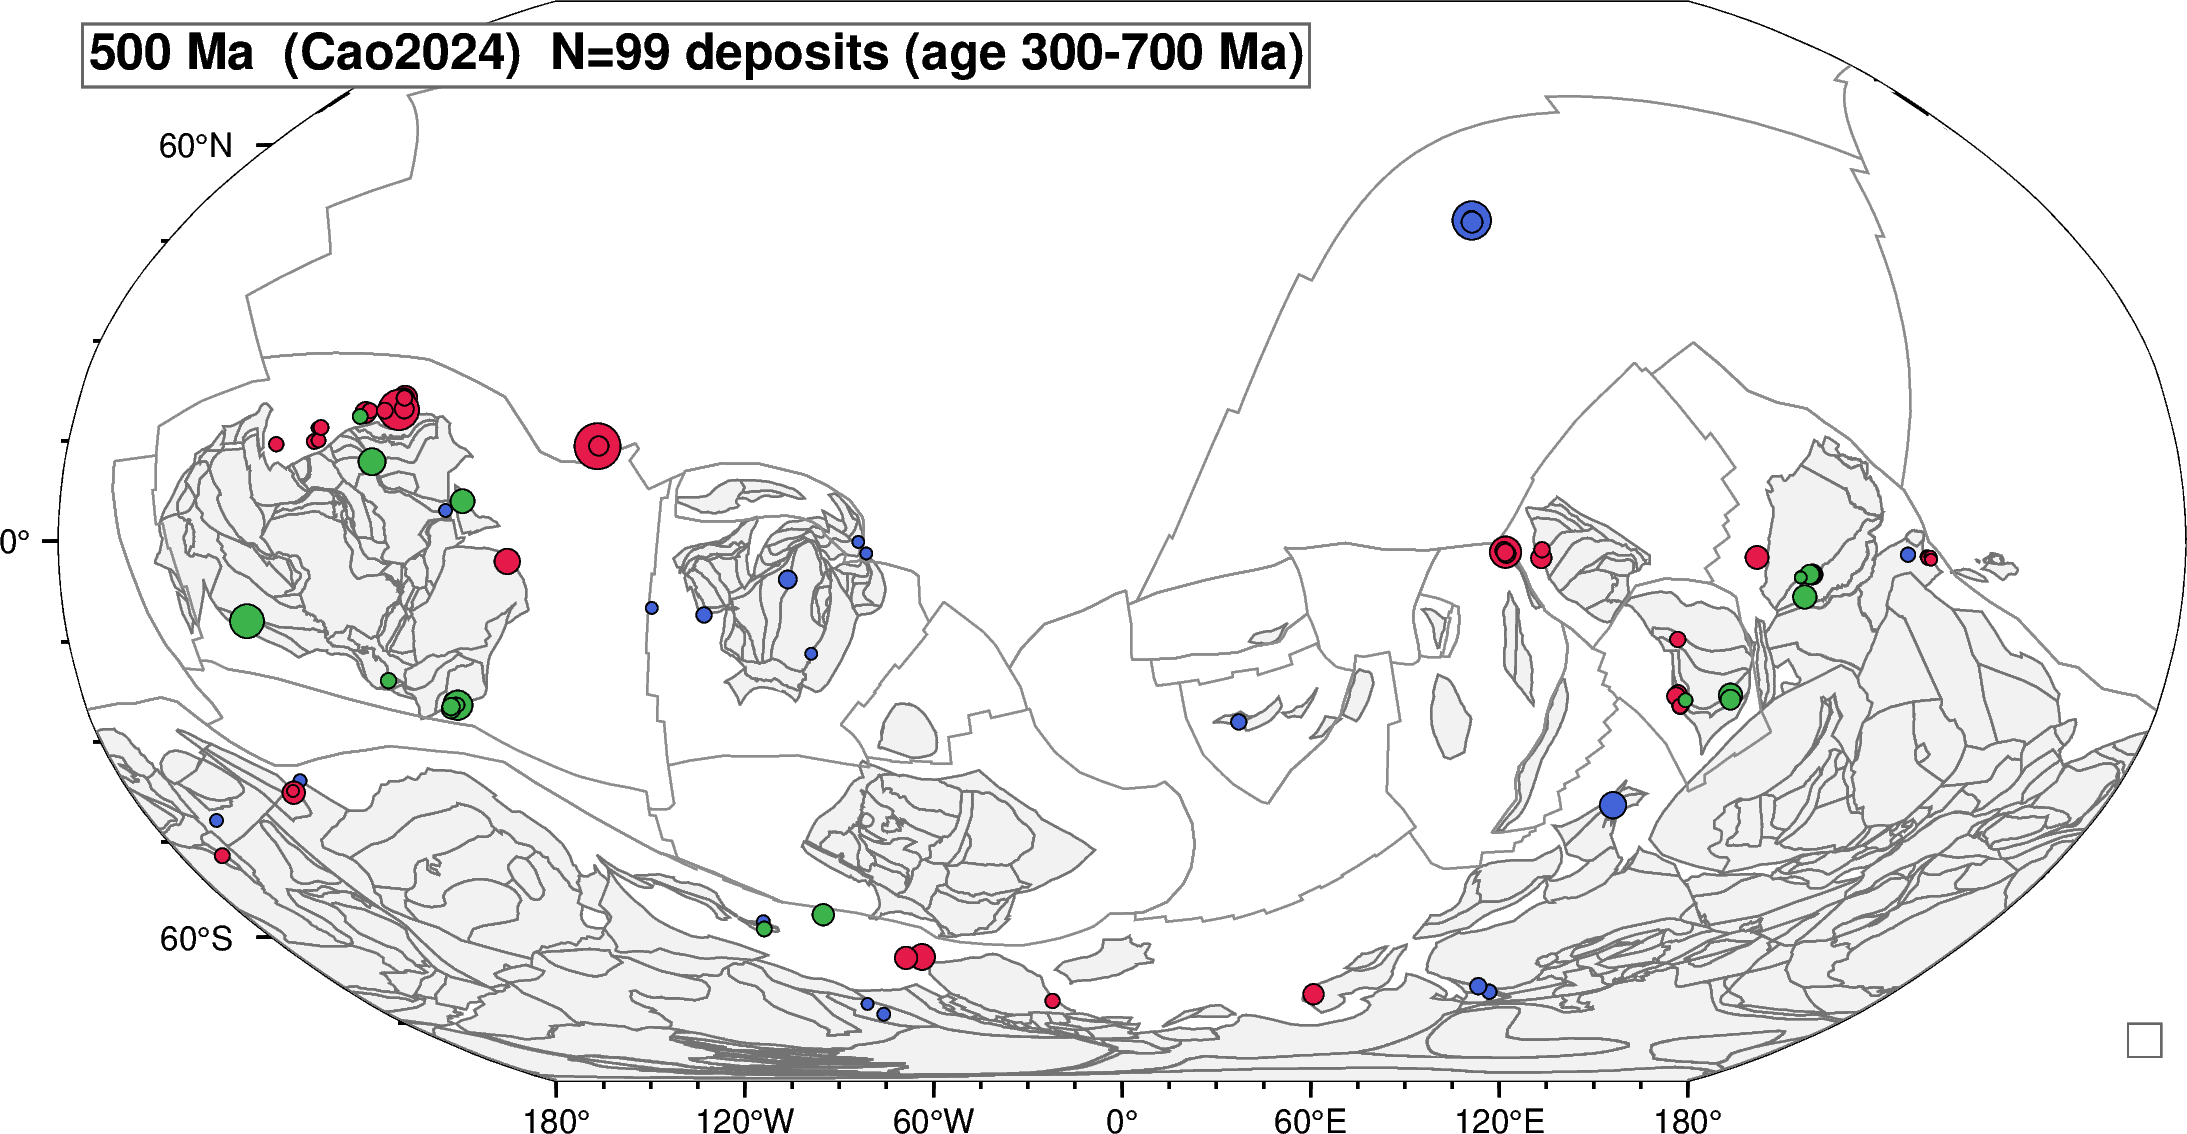

In [21]:
# --- CONFIG ---
PALEO_MODEL_NAME       = "Cao2024"        # 0-1.8 Ga plate model, matches deep-time deposit ages
PALEO_ANCHOR_PLATE_ID  = 0
PALEO_TARGET_MA        = 500              # centre of the age window (Ma)
PALEO_AGE_WINDOW_MA    = 200              # ±window around PALEO_TARGET_MA to keep + reconstruct

# --- load plate model ---
_pmm   = PlateModelManager()
_model = _pmm.get_model(PALEO_MODEL_NAME, data_dir="data/pmm_cache")
_recon = gplately.PlateReconstruction(
    rotation_model=_model.get_rotation_model(),
    topology_features=_model.get_topologies(),
    static_polygons=_model.get_static_polygons(),
)
_gplot = gplately.PlotTopologies(
    plate_reconstruction=_recon,
    coastlines=_model.get_layer("Coastlines") if "Coastlines" in _model.get_avail_layers() else None,
    continents=_model.get_layer("ContinentalPolygons") if "ContinentalPolygons" in _model.get_avail_layers() else None,
    time=PALEO_TARGET_MA,
    anchor_plate_id=PALEO_ANCHOR_PLATE_ID,
    plot_engine=gplately.PygmtPlotEngine(),
)

# --- filter deposits to age window + convert Age_Ga → Ma ---
dep_df = deposits_gdf.copy()
if "Age__Ga_" in dep_df.columns:
    dep_df["age_ma"] = pd.to_numeric(dep_df["Age__Ga_"], errors="coerce") * 1000.0
else:
    print("[warn] Age__Ga_ column not found; using synthetic age = 500 Ma for demo")
    dep_df["age_ma"] = 500.0

dep_df = dep_df.dropna(subset=["age_ma"])
lo, hi = PALEO_TARGET_MA - PALEO_AGE_WINDOW_MA, PALEO_TARGET_MA + PALEO_AGE_WINDOW_MA
snap_df = dep_df[(dep_df["age_ma"] >= lo) & (dep_df["age_ma"] <= hi)].copy()
print(f"  {len(snap_df)} deposits with age {lo:.0f}-{hi:.0f} Ma")

# --- assign plate IDs at present day ---
if len(snap_df) > 0:
    _pts0 = gplately.Points(
        plate_reconstruction=_recon,
        lons=snap_df.geometry.x.values, lats=snap_df.geometry.y.values,
        time=0, anchor_plate_id=PALEO_ANCHOR_PLATE_ID,
    )
    snap_df["plate_id"] = _pts0.plate_id

    # --- reconstruct each present-day location to PALEO_TARGET_MA using its plate ID ---
    paleo_lons, paleo_lats = [], []
    for _, row in snap_df.iterrows():
        try:
            _p = gplately.Points(
                plate_reconstruction=_recon,
                lons=[row.geometry.x], lats=[row.geometry.y],
                time=0, plate_id=[int(row["plate_id"])],
                anchor_plate_id=PALEO_ANCHOR_PLATE_ID,
            )
            rlons, rlats = _p.reconstruct(time=float(PALEO_TARGET_MA), return_array=True,
                                           anchor_plate_id=PALEO_ANCHOR_PLATE_ID)
            paleo_lons.append(float(rlons[0])); paleo_lats.append(float(rlats[0]))
        except Exception:
            paleo_lons.append(np.nan); paleo_lats.append(np.nan)
    snap_df["paleo_lon"], snap_df["paleo_lat"] = paleo_lons, paleo_lats
    snap_df = snap_df.dropna(subset=["paleo_lon", "paleo_lat"]).copy()
    print(f"  {len(snap_df)} deposits reconstructable to {PALEO_TARGET_MA} Ma")

# --- render paleogeographic reconstruction ---
fig = pygmt.Figure()
_gplot.time = PALEO_TARGET_MA
fig.basemap(region=[-180, 180, -90, 90], projection="N18c", frame="af")
fig.coast(region=[-180, 180, -90, 90], projection="N18c",
          water="white", shorelines=None)
try:
    _gplot.plot_continents(fig, fill="gray95", pen="0.5p,gray45")
    _gplot.plot_all_topological_sections(fig, pen="0.5p,gray55")
except Exception:
    pass

# Deposits at their paleo positions, coloured by Type, sized by tonnage
if len(snap_df) > 0:
    for t in sorted(snap_df[TYPE_FIELD].unique()):
        sub = snap_df[snap_df[TYPE_FIELD] == t]
        if len(sub) == 0: continue
        fig.plot(x=sub["paleo_lon"], y=sub["paleo_lat"],
                 style="cc", size=sub["marker_size_cm"].values if "marker_size_cm" in sub.columns else 0.2,
                 fill=TYPE_COLORS.get(t, "blue"), pen="0.3p,black",
                 region=[-180, 180, -90, 90], projection="N18c", label=t)

fig.text(text=f"{PALEO_TARGET_MA} Ma  ({PALEO_MODEL_NAME})  "
              f"N={len(snap_df)} deposits (age {lo:.0f}-{hi:.0f} Ma)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
if len(snap_df) > 0:
    fig.legend(position="JBR+jBR+o0.2c/0.2c", box="+gwhite+p0.4p,gray40")
fig.show(width=1100)


### How to read the paleogeographic map

- **Grey continents** — reconstructed continent geometry at `PALEO_TARGET_MA` per Cao 2024.
- **Coloured circles** — deposits whose formation age (from the `Age__Ga_` column, converted to Ma) falls within `PALEO_TARGET_MA ± PALEO_AGE_WINDOW_MA`. Each one is reconstructed from its present-day location to `PALEO_TARGET_MA` using its plate ID, so points and continents share the same reference age (the same rule used in T60 and T25 to avoid dots drifting into ocean).
- **What to watch for** — deposits that cluster near modern craton boundaries (§11-14) may have formed on the *paleo*-margins of the same cratons or on entirely different plates that later drifted into their current position. This section reads the modern tomographic craton framework against paleogeographic context: an IOCG deposit sitting on modern Australia today may have formed on the paleo-margin of a very different continent 500 Ma ago, but still within the ancient cratonic architecture that the VSH clustering picks up.


## 20. Export a tidy results table


In [22]:
results_cols = ["Deposit", TYPE_FIELD, "Country", "Tonnage", "Dist_to_Boundary_km",
                "Inside_TargetCluster", "Dist_to_HighestCluster_km"]
results_cols = [c for c in results_cols if c in deposits_gdf.columns]
results_df = pd.DataFrame(deposits_gdf[results_cols])

results_xlsx = os.path.join(OUTPUT_DIR, "deposit_boundary_distance_results.xlsx")
results_df.to_excel(results_xlsx, index=False)

print(f"Saved tidy results table -> {results_xlsx}")
results_df.sort_values("Dist_to_Boundary_km").head(10)


Saved tidy results table -> Notebooks/T72_cbf_outputs/deposit_boundary_distance_results.xlsx


,Deposit,Type,Country,Tonnage,Dist_to_Boundary_km,Inside_TargetCluster,Dist_to_HighestCluster_km
44,Changba-Lijiagou,PbZn-CD,China,12.20,7.503331e-12,False,3.226315e+02
372,Seboruco,Cu-Sed,Venezuela,0.20,8.543927e-12,False,8.543927e-12
247,Old Lead Belt (district),PbZn-MVT,USA,7.65,1.187103e-11,True,-1.187103e-11
355,Kurpandja,Cu-Sed,Russia,0.50,2.435099e+00,False,2.435099e+00
413,Kaiser Bill,IOCG,Queensland,0.14,5.377356e+00,False,2.678354e+02
262,Tordillos,Cu-Sed,Argentina,0.00,6.142570e+00,False,3.859014e+02
60,Luoba,PbZn-CD,China,1.10,6.452943e+00,False,3.622644e+02
315,Richelsdorf,Cu-Sed,Germany,0.40,7.344052e+00,False,1.254936e+02
58,Yiongzi,PbZn-CD,China,1.30,7.867173e+00,True,-7.867173e+00
170,Siding,PbZn-MVT,China,0.52,8.349879e+00,True,-8.349879e+00


## Extend this

- **Different tomography model.** Swap the six `vsh_at_*km_original.tif` files for a different global VSH product (e.g. a newer tomography model at the same 150-200 km depths) and re-run — the whole PCA → KMeans → boundaries pipeline is data-blind. Keep the six-depth stack cadence for direct comparison.
- **Different depth range.** Try 100-150 km (shallower — captures the "thermal" lithosphere) or 200-250 km (deeper — captures the cratonic keel proper). Adjust `DEPTHS` in the CONFIG cell.
- **Different clustering.** Swap `KMeans` for `HDBSCAN` or Gaussian mixture models — useful when the true classes have very uneven populations. Change `N_CLUSTERS` via the elbow plot in §5.
- **Different deposit database.** Point `DEPOSITS_SHP` at USGS MRDS, GEUS Greenland, or your own compilation. Any point shapefile with `Type`, `Ore_Tonnage` and `Age` columns will drop straight in.
- **Different paleo-age target.** In §19, change `PALEO_TARGET_MA` and `PALEO_AGE_WINDOW_MA` to interrogate a different time window. Try 1200 Ma ± 200 Ma to see Mesoproterozoic deposit distribution, or 100 Ma ± 50 Ma for Cretaceous-forming deposits.
- **Cluster labels through time.** Overlay the modern cluster-boundary polylines onto the paleogeographic reconstruction in §19 (rotated by their host-plate rotations) to see which deposits formed on the ancient paleo-margin of the same craton they sit on today, and which were later transferred.

## References

**Primary papers describing this workflow**

- **Shirmard, H., Mather, B., Farahbakhsh, E., Czarnota, K. & Müller, R.D. (2025).** Craton boundary detection from full-waveform tomography model reveals links to critical metal deposits. *Geoscience Frontiers* 16, 102176. doi:10.1016/j.gsf.2025.102176. *(Methodology paper — VSH clustering + boundary extraction workflow implemented in §1-15 of this notebook. Establishes the \~85%-of-Cu+Pb+Zn-within-\~120 km figure quoted in the introduction.)*
- **Shirmard, H., Mather, B., Farahbakhsh, E., O'Neill, C. & Müller, R.D. (2026).** How subduction evolution drives sediment-hosted mineralisation along craton edges. *Nature Communications* (accepted, in press). doi:10.1038/s41467-026-74134-5. *(Companion paper — quantifies the 800-1800 km subduction-to-mineralised-craton-edge distance, and links it to mantle return-flow-driven lithospheric weakening. §19 mirrors the paleo-reconstruction step used there.)*
- **Shirmard, H., Farahbakhsh, E., Mather, B., Czarnota, K. & Müller, R.D.** (in review, *Tectonics*). *From Geodynamic Preconditioning to Mineral System Fertility: A Spatio-Temporal Analysis of Craton-Edge Sediment-Hosted Deposits.* *(Companion spatio-temporal analysis paper; the bundled `All_Deposits.shp` includes attributes used in that study.)*
- **Shirmard, H., Farahbakhsh, E., Czarnota, K. & Müller, R.D. (2025).** Automated Detection of Mineralization-Related Craton Structures Using Geophysical Data and Unsupervised Machine Learning. *Economic Geology.* *(Companion regional-scale case study — Gawler craton, magnetic + gravity data, 400+ features, K-means vs SOM clustering. Same authors, complementary data type to the global REVEAL workflow implemented here.)*

**Datasets and models bundled or reconstructed against**

- **Thrastarson, S., van Herwaarden, D.-P., Noe, S., Schiller, C.J. & Fichtner, A. (2024).** REVEAL: a global full-waveform inversion model. *Bull. Seismol. Soc. Am.* 114(3), 1392-1406. doi:10.1785/0120230273. *(Source of `vsh_at_*km_original.tif`. Full-waveform inversion, 33 s minimum period, 2366 earthquakes, 6 million waveforms, 305 quasi-Newton iterations.)*
- **Fichtner, A., Ritsema, J. & Thrastarson, S. (2025).** A high-resolution discourse on seismic tomography. *Proceedings of the Royal Society A* 481, 20240955. doi:10.1098/rspa.2024.0955. *(Perspective / user guide on how to choose between and interpret global seismic-tomography models — recommended background reading for anyone using REVEAL.)*
- **Hoggard, M.J., Czarnota, K., Richards, F.D., Huston, D.L., Jaques, A.L., Ghelichkhan, S. et al. (2020).** Global distribution of sediment-hosted metals controlled by craton edge stability. *Nature Geoscience* 13(7), 504-510. doi:10.1038/s41561-020-0593-2. *(Source of the 2166-deposit compilation in `All_Deposits.shp`. First paper to quantify the sediment-hosted-metal / thick-thin-lithosphere-transition association at \~200 km precision.)*
- **Artemieva, I.M. (2006).** Global 1°×1° thermal model TC1 for the continental lithosphere: Implications for lithosphere secular evolution. *Tectonophysics.* *(TC1 tectonic-age model used by Shirmard et al. 2025 to distinguish true cratons from other thick-lithosphere features.)*

**Plate model + software (§19)**

- **Cao, X., Collins, A.S., Pisarevsky, S.A., Flament, N., Li, S., Hasterok, D. & Müller, R.D. (2024).** Earth's tectonic and plate boundary evolution over 1.8 billion years. *Geoscience Frontiers* 15, 101922. doi:10.1016/j.gsf.2024.101922. *(Cao 2024 plate model used in §19 to reconstruct deposit paleopositions across the deposit-formation-age range.)*
- **Mather, B.R., Müller, R.D., Zahirovic, S., et al. (2024).** Deep time spatio-temporal data analysis using pyGPlates with PlateTectonicTools and GPlately. *Geoscience Data Journal* 11, 3-10. doi:10.1002/gdj3.185. *(GPlately / pyGPlates software used throughout the suite and in §19 for the plate-model reconstruction.)*


## Outputs written to `OUTPUT_DIR`

| File | Description |
|---|---|
| `VSH_merged.csv` | Merged raw VSH values across all depth slices |
| `pca_VSH.csv` | PCA scores per grid point |
| `kmeans_VSH.csv` | PCA scores + cluster labels |
| `kmeans_clustering_VSH.tif` | Rasterized cluster map |
| `Kmeans_Boundaries_VSH.shp` | Cluster boundary polylines |
| `Deposits_with_distance.shp` | Deposits + `Dist_to_Boundary_km` + `Tonnage` |
| `cluster_boundaries_vs_deposits_map.png` | Boundary-only map (lon/lat) |
| `cluster_boundaries_vs_deposits_mollweide.png` | Boundary-only map, Mollweide projection |
| `cluster_filled_map_continents.png` | **Filled, colorful cluster map** clipped to continents, Mollweide projection |
| `highest_velocity_cluster_boundary_map.png` | Map of just the target cluster's boundary (`TARGET_CLUSTER_RANK`) |
| `weighted_CDF_all_deposits.png` | Combined weighted CDF (distance to nearest of *any* cluster boundary) |
| `weighted_CDF_by_type.png` | Per-type weighted CDF grid |
| `weighted_CDF_overlay_by_type.png` | All types + combined curve overlaid on one plot |
| `deposit_boundary_distance_results.xlsx` | Tidy results table |

`Magmatic_Ni` and `VMS` are excluded everywhere via `EXCLUDE_TYPES` in the Config cell — remove
them from that list if you want those types back in.
